# 2026-09-30 Tests 2 and 3: HII-like stage residuals and a common mixture weight

## Material Passport
- Source: [the requested conversation](https://chatgpt.com/c/6abbd62b-d27c-83ec-8ff0-fc933bdbc716), latest two exchanges retrieved on 2026-09-30.
- Exchange IDs: `c1b550e6-5a56-4c28-a9bb-976705fb73b1` and `98716de8-dfd2-4362-b02e-a6167ee27231`.
- Local provenance: `20260930_check_emission_line_fading_BPT_ratios_Halpha_sigma_SF_NSF_by_stage.ipynb`, ultimately derived from source cell 22/39 of the 20260909 notebook.
- Scope: **Test 2**, dependence of HII-like N2/S2/O3 ratios on stage after matching local conditions; **Test 3**, conditional consistency of one HII-like/diffuse-like weight with all three ratios.
- Design: observational and exploratory; galaxies are resampling units. Input products and source notebooks remain unchanged.

Run all cells from the `further` directory. Each scientific question has its own
plotting cell. This is not a test of the HI-only reservoir model.

The observational SF/NSF labels are recorded only for a downstream check.
Neither label nor any BPT class is used to choose endpoint candidates.

## Hypotheses and limits

**Test 2:** $\log R_k=F_k(\log\Sigma_\star,R/R_e)+\Delta_{k,\rm stage}$,
for $k=\{N2,S2,O3\}$ in successively stricter HII-like subsets.
The pre-peak reference $F_k$ is a two-dimensional piecewise-constant surface.
Only cells with at least three supported galaxies in **every** stage are compared.
No extrapolation fills holes. Matching both axes controls their joint
distribution; it does not control metallicity, ionization parameter or stellar age.

**Test 3:** in linear ratios,
$\mathbf R=(1-w)\mathbf H+w\mathbf D$.
$w$ is an Halpha luminosity weight; O3/Hbeta shares it only under equal endpoint
Balmer decrements. The corrected-map equality is checked, rather than assumed.
It may be imposed by the dust-correction pipeline and is not evidence that
the physical components have equal intrinsic decrements.

No AGN catalogue or resolved HII segmentation is supplied. A central exclusion
and a local Halpha-peak distance proxy reduce some contaminants; they do not
prove purity or exclude off-centre AGN/shocks. Here **HII-like** and
**diffuse-like** describe selections, not established physical components.
Thresholds below are an exploratory sensitivity grid, not calibrated boundaries.

In [3]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / "v3tk_v7.6.8"
CATALOG_PATH = PROJECT_ROOT / "mauve_master_wiki_newclass.fits"
GEOMETRY_PATH = PROJECT_ROOT / "MAUVE_effective_radii.csv"

MASS_FILE_PATTERN = "{galid}_spatial_binning_maps_further.fits"
SFR_FILE_PATTERNS = (
    "{galid}_gas_bin_maps_further.fits",
    "{galid}_gas_BIN_maps_further.fits",
)
EW_FILE_PATTERNS = (
    "{galid}_proxy_EW_maps_further.fits",
    "{galid}_proxy_EW_maps.fits",
)
MASK_FILE_PATTERN = "{galid}_mask.fits"
SFH_FILE_PATTERN = "{galid}_sfh_maps.fits"

MASS_HDU = "LOGMASS_SURFACE_DENSITY"
BIN_HDU_MASS = "BINID"
BIN_HDU_GAS = "BIN_ID"
SFR_HDU = "LOGSFR_SURFACE_DENSITY_HII"
# All-spaxel ordinate only; SFR_HDU remains the original SF-selection map.
ALL_SFR_HDU = "LOGSFR_SURFACE_DENSITY"
EW_HDU = "PROXY_EWHA"
HALPHA_SIGMA_OBS_HDU = "HA6562_SIGMA"
HALPHA_SIGMA_CORR_HDU = "HA6562_SIGMA_CORR"
MASK_TABLE_HDU = "MASKFILE"
MASK_COLUMN = "MASK"
SFH_SNR_POSTFIT_HDU = "SNR_POSTFIT"

EW_HA_MIN = 6.0
HALPHA_SIGMA_MAX = 45.0
SFH_SNR_POSTFIT_MIN = 25.0
I_MAX_PRIMARY = 80.0
MIN_VALID_PIXELS_PER_BIN = 50
MIN_SF_PIXELS_PER_BIN = 20
WCS_TOLERANCE_ARCSEC = 0.05

SIGMA_BIN_WIDTH = 0.25
RADIUS_BIN_WIDTH = 0.25
FIXED_RELIABLE_RANGES = {"log_sigma_star": (7.0, 9.5), "radius_re": (0.0, 2.5)}
MASS_CONTOUR_LEVEL = 7.5

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.grid": False,
})

print(f"Project root: {PROJECT_ROOT}")
print("Scope: Test 2 HII-like stage invariance; Test 3 common linear-ratio mixing weight")
print("No additional inclination correction is applied to either surface-density map.")

# Keep category colours fixed across galaxies; these encode categories, not identity.
BALMER_LINES = ("HB4861", "HA6562")
LINE_LABELS = (r"H$\beta$", r"H$\alpha$")
CATEGORY_COLORS = {"SF": "#2166ac", "ND": "#e69f00", "NSF": "#b2182b"}
REASON_LABELS = (
    "BPT: stable non-HII", "BPT: weak/ambiguous/unavailable", "HII SFR unavailable",
    "EW unavailable", "EW <= 6", "Dispersion unavailable", "Dispersion >= 45",
)
REASON_COLORS = ("#b2182b", "#984ea3", "#999999", "#a6cee3", "#33a02c", "#cab2d6", "#e66101")


N_BOOTSTRAP = 10_000
RANDOM_SEED = 42
MIN_SUPPORT_GALAXIES = 3
MIN_SF_PIXELS_FOR_SUPPORT = MIN_SF_PIXELS_PER_BIN
STAGE_COLORS = {
    "pre-peak": "#2166ac",
    "close-to-peak": "#1a9850",
    "post-peak": "#d73027",
}
COMPONENT_COLORS = {
    "occupancy": "#2166ac",
    "survivor_intensity": "#e69f00",
    "total_hii": "#111111",
}


import warnings

COLOR_TABLE_PATH = PROJECT_ROOT / "MAUVE_galaxy_colors.dat"
CATEGORY_ORDER = ("SF", "NSF", "ND")
MIN_CATEGORY_PIXELS_PER_BIN = 20
DIAGNOSTIC_MIN_PIXELS_PER_BIN = 20
DIAGNOSTIC_ORDER = ("log_OIII_Hb", "log_NII_Ha", "log_SII_Ha", "log_OI_Ha", "sigma_Ha")
DIAGNOSTIC_LABELS = {
    "log_OIII_Hb": r"$\log_{10}([\mathrm{O\,III}]5007/\mathrm{H}\beta)$",
    "log_NII_Ha": r"$\log_{10}([\mathrm{N\,II}]/\mathrm{H}\alpha)$",
    "log_SII_Ha": r"$\log_{10}(([\mathrm{S\,II}]6716+6731)/\mathrm{H}\alpha)$",
    "log_OI_Ha": r"$\log_{10}([\mathrm{O\,I}]/\mathrm{H}\alpha)$",
    "sigma_Ha": r"$\sigma_{\mathrm{H}\alpha,\mathrm{intr}}$ [km s$^{-1}$]",
}
BPT_LINE_ORDER = ("HA6562", "HB4861", "OIII5006", "NII6583", "SII_SUM")
BPT_LINE_LABELS = {
    "HA6562": r"H$\alpha$",
    "OIII5006": r"[O III]$\lambda5007$",
    "NII6583": r"[N II]$\lambda6583$",
    "SII_SUM": r"[S II]$\lambda\lambda6716,6731$",
}

BPT_LINE_LABELS["HB4861"] = r"H$\beta$"

SOURCE_NOTEBOOK_SHA256 = '6cceb82881b9ced60fad75aaec2e66f4bf14fdf1678fab86f11f6213bf93fc4f'

from scipy.ndimage import gaussian_filter, maximum_filter, distance_transform_edt
from itertools import product
import hashlib

N_BOOT = 2000  # whole-galaxy draws; editable for final convergence checks
MIN_GAL = 3
MIN_CELL_PIXELS = 20
MIN_CELL_USABLE = 50
MASS_EDGES_2D = np.arange(7.0, 9.5 + .01, .5)
RADIAL_EDGES_2D = np.arange(.5, 2.5 + .01, .5)
EW_GRID = (12., 25., 50.)  # Angstrom
LOG_LHA_GRID = (38.5, 39., 39.5)  # erg/s/kpc^2, log10
SIGMA_GRID = (45., 35.)  # km/s
CENTRAL_MIN_RE = .5
PEAK_MIN_LOG_LHA = 39.5
PEAK_DISTANCE_PIXELS = 3.
HII_REQUIRE_PEAK = False  # brightness/EW/sigma primary; compactness sensitivity below
DIG_LOG_LHA_MAX_GRID = (38.5, 39.)
DIG_EW_RANGE = (6., 25.)
DIG_SIGMA_MAX = 45.
BALMER_REL_TOL = 1e-3
MIN_ENDPOINT_REL_SEPARATION = .10
TEST2_EQUIVALENCE_MARGIN_DEX = .05  # exploratory practical tolerance, not from literature
JOINT_RESIDUAL_TOL_DEX = .05  # descriptive held-out tolerance, not a calibrated p-value
RATIO_KEYS = ("N2", "S2", "O3")
RATIO_NAMES = {"N2": "[N II]/Halpha", "S2": "[S II]/Halpha", "O3": "[O III]/Hbeta"}
RATIO_NUMERATORS = ("NII6583", "SII_SUM", "OIII5006")
RATIO_DENOMINATORS = ("HA6562", "HA6562", "HB4861")
LINE_KEYS = ("HA6562", "HB4861", "NII6583", "SII_SUM", "OIII5006")

PURITY_GRID = pd.DataFrame([
    {"selection": f"E{ew:g}_L{sb:g}_S{sig:g}", "ew_min":ew, "log_lha_min":sb, "sigma_max":sig,
     "central_min":CENTRAL_MIN_RE, "require_peak":HII_REQUIRE_PEAK}
    for ew,sb,sig in product(EW_GRID,LOG_LHA_GRID,SIGMA_GRID)
])
PURITY_PATH = ("E12_L38.5_S45", "E25_L39_S35", "E50_L39.5_S35")
HII_ENDPOINT_SELECTION = PURITY_PATH[-1]
PURITY_GRID = pd.concat([PURITY_GRID, pd.DataFrame([
    {**PURITY_GRID.loc[PURITY_GRID.selection.eq(PURITY_PATH[1])].iloc[0].to_dict(),
     "selection":"P2_compact", "require_peak":True},
    {**PURITY_GRID.loc[PURITY_GRID.selection.eq(PURITY_PATH[1])].iloc[0].to_dict(),
     "selection":"P2_central_0.75", "central_min":.75}
])],ignore_index=True)
display(PURITY_GRID)
print('Primary nested path:', PURITY_PATH)
print('Fixed HII-like endpoint:', HII_ENDPOINT_SELECTION)
print('Bootstrap draws:', N_BOOT)
SOURCE_NOTEBOOK_NAME = '20260930_check_emission_line_fading_BPT_ratios_Halpha_sigma_SF_NSF_by_stage.ipynb'
SOURCE_NOTEBOOK_HASH = 'b8d6b5776172abcf1273789d464b3baf93af7b6967435c20274ad9481ecf5a4e'

Project root: /Users/Igniz/Desktop/ICRAR/further
Scope: Test 2 HII-like stage invariance; Test 3 common linear-ratio mixing weight
No additional inclination correction is applied to either surface-density map.
Primary nested path: ('E12_L38.5_S45', 'E25_L39_S35', 'E50_L39.5_S35')
Fixed HII-like endpoint: E50_L39.5_S35
Bootstrap draws: 2000


,selection,ew_min,log_lha_min,sigma_max,central_min,require_peak
0,E12_L38.5_S45,12.0,38.5,45.0,0.50,False
1,E12_L38.5_S35,12.0,38.5,35.0,0.50,False
2,E12_L39_S45,12.0,39.0,45.0,0.50,False
3,E12_L39_S35,12.0,39.0,35.0,0.50,False
4,E12_L39.5_S45,12.0,39.5,45.0,0.50,False
5,E12_L39.5_S35,12.0,39.5,35.0,0.50,False
6,E25_L38.5_S45,25.0,38.5,45.0,0.50,False
7,E25_L38.5_S35,25.0,38.5,35.0,0.50,False
8,E25_L39_S45,25.0,39.0,45.0,0.50,False
9,E25_L39_S35,25.0,39.0,35.0,0.50,False


## Inherited product readers, geometry and observational labels
Masks, instrumental dispersion subtraction, detection thresholds, combined-system geometry and WCS checks are retained. The finite HII-SFR map affects the ancillary SF label only; it does not enter the new HII-like selection.

In [5]:
def normalise_stage_label(value) -> str:
    mapping = {
        1: "pre-peak", 1.0: "pre-peak", "1": "pre-peak",
        2: "close-to-peak", 2.0: "close-to-peak", "2": "close-to-peak",
        3: "post-peak", 3.0: "post-peak", "3": "post-peak",
        "prepeak": "pre-peak", "pre-peak": "pre-peak",
        "close-to-peak": "close-to-peak", "closetopeak": "close-to-peak",
        "near-peak": "close-to-peak", "postpeak": "post-peak", "post-peak": "post-peak",
    }
    key = value if isinstance(value, (int, float)) else str(value).strip().lower().replace(" ", "")
    if key not in mapping:
        raise ValueError(f"Unrecognised RPS/infall stage label: {value!r}")
    return mapping[key]

def first_existing(paths):
    for path in paths:
        for candidate in (path, Path(str(path) + ".gz")):
            if candidate.exists():
                return candidate
    return None

def load_fits_map(path: Path, hdu_name: str, *, return_header: bool = False):
    with fits.open(path, memmap=True) as hdul:
        names = {hdu.name.upper() for hdu in hdul}
        if hdu_name.upper() not in names:
            raise KeyError(f"{path}: missing HDU {hdu_name}; available={sorted(names)}")
        hdu = hdul[hdu_name]
        data = np.asarray(hdu.data, dtype=float).copy()
        header = hdu.header.copy()
    return (data, header) if return_header else data

def load_ngist_mask(path: Path, shape):
    with fits.open(path, memmap=True) as hdul:
        if MASK_TABLE_HDU not in hdul:
            raise KeyError(f"{path}: missing table HDU {MASK_TABLE_HDU}")
        table = hdul[MASK_TABLE_HDU].data
        if MASK_COLUMN not in table.names:
            raise KeyError(f"{path}: missing mask column {MASK_COLUMN}; available={table.names}")
        flat = np.asarray(table[MASK_COLUMN], dtype=int)
    if flat.size != int(np.prod(shape)):
        raise ValueError(f"{path}: mask length {flat.size} cannot reshape to {shape}")
    return flat.reshape(shape)

def celestial_wcs_separation_arcsec(header_a, header_b, shape):
    wa, wb = WCS(header_a).celestial, WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        return np.inf
    ny, nx = shape
    x = np.array([0, nx - 1, 0, nx - 1, (nx - 1) / 2])
    y = np.array([0, 0, ny - 1, ny - 1, (ny - 1) / 2])
    raa, deca = wa.pixel_to_world_values(x, y)
    rab, decb = wb.pixel_to_world_values(x, y)
    cosd = np.cos(np.deg2rad((deca + decb) / 2))
    return float(np.nanmax(np.hypot((raa - rab) * cosd, deca - decb)) * 3600.0)

def tangent_offsets_arcsec(ra_deg, dec_deg, ra0_deg, dec0_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(float(ra0_deg)), np.deg2rad(float(dec0_deg))
    dra = (ra - ra0 + np.pi) % (2 * np.pi) - np.pi
    cosc = np.sin(dec0) * np.sin(dec) + np.cos(dec0) * np.cos(dec) * np.cos(dra)
    with np.errstate(divide="ignore", invalid="ignore"):
        east = np.cos(dec) * np.sin(dra) / cosc
        north = (np.cos(dec0) * np.sin(dec) - np.sin(dec0) * np.cos(dec) * np.cos(dra)) / cosc
    return east * 206264.806247, north * 206264.806247

def calculate_deprojected_radius(shape, header, component_rows: pd.DataFrame):
    # Minimum elliptical R/Re over the physical components of one product.
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("No celestial WCS available for radius calculation")
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = wcs.pixel_to_world_values(xx, yy)
    radius = np.full(shape, np.inf, dtype=float)
    for _, component in component_rows.iterrows():
        east, north = tangent_offsets_arcsec(
            ra, dec, component.center_ra_deg, component.center_dec_deg
        )
        pa = np.deg2rad(float(component.pa_deg_east_of_north))
        major = east * np.sin(pa) + north * np.cos(pa)
        minor = east * np.cos(pa) - north * np.sin(pa)
        component_radius = np.sqrt(
            (major / float(component.a_re_arcsec)) ** 2
            + (minor / float(component.b_re_arcsec)) ** 2
        )
        radius = np.minimum(radius, component_radius)
    radius[~np.isfinite(radius)] = np.nan
    return radius

def intrinsic_sigma_from_maps(sigma_obs, sigma_corr):
    sigma2 = np.asarray(sigma_obs, dtype=float) ** 2 - np.asarray(sigma_corr, dtype=float) ** 2
    result = np.full(sigma2.shape, np.nan, dtype=float)
    valid = np.isfinite(sigma2) & (sigma2 > 0)
    result[valid] = np.sqrt(sigma2[valid])
    return result

def load_galaxy_maps(row, geometry):
    mass, mass_header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    mass_bin = load_fits_map(row.mass_path, BIN_HDU_MASS)
    gas_bin, gas_header = load_fits_map(row.sfr_path, BIN_HDU_GAS, return_header=True)
    sfr = load_fits_map(row.sfr_path, SFR_HDU)
    ew_ha = load_fits_map(row.ew_path, EW_HDU)
    sigma_obs = load_fits_map(row.sfr_path, HALPHA_SIGMA_OBS_HDU)
    sigma_corr = load_fits_map(row.sfr_path, HALPHA_SIGMA_CORR_HDU)
    snr_postfit = load_fits_map(row.sfh_path, SFH_SNR_POSTFIT_HDU)
    shapes = {a.shape for a in (
        mass, mass_bin, gas_bin, sfr, ew_ha, sigma_obs, sigma_corr, snr_postfit
    )}
    if len(shapes) != 1:
        raise ValueError(f"{row.GALID}: map shape mismatch {sorted(shapes)}")
    wcs_sep = celestial_wcs_separation_arcsec(mass_header, gas_header, mass.shape)
    if not np.isfinite(wcs_sep) or wcs_sep > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: mass/gas WCS mismatch {wcs_sep:.4f} arcsec")
    ngist_mask = load_ngist_mask(row.mask_path, mass.shape)
    components = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].copy()
    radius_re = calculate_deprojected_radius(mass.shape, mass_header, components)
    sigma_intrinsic = intrinsic_sigma_from_maps(sigma_obs, sigma_corr)
    valid = (
        np.isfinite(mass) & np.isfinite(gas_bin) & (ngist_mask == 0) & np.isfinite(radius_re)
    )
    sf = (
        valid & np.isfinite(sfr) & np.isfinite(ew_ha) & (ew_ha > EW_HA_MIN)
        & np.isfinite(sigma_intrinsic) & (sigma_intrinsic < HALPHA_SIGMA_MAX)
    )
    maps = {
        "log_sigma_star": mass,
        "log_sigma_sfr": sfr,
        "radius_re": radius_re,
        "snr_postfit": snr_postfit,
        "valid_disc_mask": valid,
        "sf_mask": sf,
        "mass_header": mass_header,
        "wcs_separation_arcsec": wcs_sep,
    }
    return add_detection_categories(maps, row, ew_ha, sigma_intrinsic)

def add_detection_categories(maps, row, ew_ha, sigma_intrinsic):
    """Use Balmer-only ND and preserve the original SF selection exactly."""
    valid, sf = maps["valid_disc_mask"], maps["sf_mask"]
    detected = {}
    invalid_any = np.zeros(valid.shape, dtype=bool)
    with fits.open(row.sfr_path, memmap=True) as hdul:
        header = hdul[0].header
        sn_cut, flux_floor = float(header["CUT_SN"]), float(header["NOISE"])
        if not (np.isfinite(sn_cut) and sn_cut > 0 and np.isfinite(flux_floor) and flux_floor > 0):
            raise ValueError(f"{row.GALID}: invalid detection thresholds")
        if str(header["BPTMODE"]).strip().lower() != "both":
            raise ValueError(f"{row.GALID}: expected the original both-BPT selection")
        for line in BALMER_LINES:
            flux = np.asarray(hdul[line + "_FLUX"].data, dtype=float)
            error = np.asarray(hdul[line + "_FLUX_ERR"].data, dtype=float)
            if flux.shape != valid.shape or error.shape != valid.shape:
                raise ValueError(f"{row.GALID}: {line} shape mismatch")
            measurable = np.isfinite(flux) & np.isfinite(error) & (error > 0)
            invalid_any |= ~measurable
            with np.errstate(divide="ignore", invalid="ignore"):
                detected[line] = measurable & (flux / error >= sn_cut) & (flux >= flux_floor)
        # Do not use the old NII_HA_BPT / SII_HA_BPT ratio HDUs as class maps.
        nii = np.asarray(hdul["NII_BPT"].data).copy()
        sii = np.asarray(hdul["SII_BPT"].data).copy()
        for name, arr in (("NII_BPT", nii), ("SII_BPT", sii)):
            if arr.shape != valid.shape or not np.isin(arr[valid], [-1, 0, 1, 2, 3]).all():
                raise ValueError(f"{row.GALID}: invalid {name} class map")
        provenance = {key: header.get(key, "not recorded")
                      for key in ("CUT_SN", "NOISE", "BPTMODE", "BPTLIMIT", "DUSTLAW")}
    balmer_detected = detected["HA6562"] & detected["HB4861"]
    if np.any(sf & ~balmer_detected):
        raise AssertionError(f"{row.GALID}: original SF includes a Balmer non-detection")
    nd = valid & ~balmer_detected
    nsf = valid & balmer_detected & ~sf
    # Exclusive bookkeeping, in this order: HII gate -> EW gate -> sigma gate.
    # This is a first-failed-gate decomposition, not a unique physical cause.
    has_sfr = np.isfinite(maps["log_sigma_sfr"])
    stable_non_hii = np.isin(nii, [2, 3]) | np.isin(sii, [2, 3])
    both_hii = (nii == 1) & (sii == 1)
    conditions = (
        ~has_sfr & stable_non_hii,
        ~has_sfr & ~both_hii,
        ~has_sfr,
        ~np.isfinite(ew_ha),
        ew_ha <= EW_HA_MIN,
        ~np.isfinite(sigma_intrinsic),
        sigma_intrinsic >= HALPHA_SIGMA_MAX,
    )
    remainder = nsf.copy()
    reasons = {}
    for label, condition in zip(REASON_LABELS, conditions):
        reasons[label] = remainder & condition
        remainder &= ~condition
    if remainder.any():
        raise AssertionError(f"{row.GALID}: unexplained detected non-SF pixels")
    category_sum = sf.astype(np.int8) + nd + nsf
    assert np.array_equal(category_sum, valid.astype(np.int8))
    assert np.array_equal(np.sum(list(reasons.values()), axis=0), nsf.astype(int))
    maps.update({
        "nd_mask": nd, "nsf_mask": nsf, "balmer_detected_mask": balmer_detected,
        "line_detected": detected, "nsf_reasons": reasons,
        "nd_invalid_mask": nd & invalid_any,
        "nd_measured_below_cut_mask": nd & ~invalid_any,
        "detection_provenance": provenance,
    })
    return maps

## Live product inventory and exclusions

In [7]:
def read_master_catalogue(path):
    with fits.open(path) as hdul:
        table = hdul[1].data
        frame = pd.DataFrame({
            "galaxy": [str(value).strip() for value in table["Galaxy"]],
            "logMstar": np.asarray(table["logMstar"], dtype=float),
            "stage_code": np.asarray(table["class"], dtype=float),
        })
    frame["stage"] = frame.stage_code.map(normalise_stage_label)
    return frame


def discover_products(data_root):
    rows = []
    for folder in sorted(path for path in data_root.iterdir()
                         if path.is_dir() and not path.name.endswith("_logs")):
        galid = folder.name
        rows.append({
            "GALID": galid,
            "mass_path": folder / MASS_FILE_PATTERN.format(galid=galid),
            "sfr_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in SFR_FILE_PATTERNS
            ]),
            "ew_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in EW_FILE_PATTERNS
            ]),
            "mask_path": folder / MASK_FILE_PATTERN.format(galid=galid),
            "sfh_path": first_existing([
                folder / SFH_FILE_PATTERN.format(galid=galid)
            ]),
        })
    return pd.DataFrame(rows)


STAGE_ORDER = ("pre-peak", "close-to-peak", "post-peak")
PANEL_ORDER = STAGE_ORDER + ("all stages",)
STAGE_LABELS = {
    "pre-peak": "Pre-peak",
    "close-to-peak": "Close-to-peak",
    "post-peak": "Post-peak",
    "all stages": "All stages",
}

master = read_master_catalogue(CATALOG_PATH)
geometry = pd.read_csv(GEOMETRY_PATH)
required_geometry = {
    "galaxy", "notebook_product_id", "mauve_infall_stage", "center_ra_deg",
    "center_dec_deg", "inclination_deg", "pa_deg_east_of_north",
    "a_re_arcsec", "b_re_arcsec",
}
missing_geometry = required_geometry - set(geometry.columns)
if missing_geometry:
    raise KeyError(f"{GEOMETRY_PATH}: missing columns {sorted(missing_geometry)}")

geometry = geometry.merge(
    master[["galaxy", "logMstar", "stage"]], on="galaxy", how="left",
    validate="one_to_one",
)
geometry["stage_from_geometry"] = geometry.mauve_infall_stage.map(normalise_stage_label)
if not geometry.stage.eq(geometry.stage_from_geometry).all():
    raise RuntimeError("Stage disagreement between the master and effective-radius catalogues")

product_meta = []
for galid, group in geometry.groupby("notebook_product_id", sort=False):
    if group.stage.nunique() != 1:
        raise RuntimeError(f"{galid}: physical components have inconsistent stages")
    product_meta.append({
        "GALID": galid,
        "components": ",".join(group.galaxy),
        "stage": group.stage.iloc[0],
        "inclination": float(group.inclination_deg.max()),
    })

inventory = pd.DataFrame(product_meta).merge(
    discover_products(DATA_ROOT), on="GALID", how="left", validate="one_to_one"
)
candidates = inventory.loc[
    inventory.stage.isin(STAGE_ORDER) & inventory.inclination.lt(I_MAX_PRIMARY)
].sort_values(["stage", "GALID"]).reset_index(drop=True)

# This first pass performs full live QC and records only range/count summaries.
# Maps are not cached so the combined notebook does not retain all galaxies in memory.
qc_rows = []
for row in candidates.itertuples(index=False):
    flags = []
    for label, path in (("mass", row.mass_path), ("sfr", row.sfr_path),
                        ("ew", row.ew_path), ("mask", row.mask_path),
                        ("sfh", row.sfh_path)):
        if not isinstance(path, Path) or not path.exists():
            flags.append(f"missing_{label}_product")
    maps = None
    if not flags:
        try:
            maps = load_galaxy_maps(row, geometry)
            valid = maps["valid_disc_mask"]
            if np.any(maps["sf_mask"] & ~valid):
                flags.append("sf_not_subset_of_valid")
        except Exception as exc:
            flags.append(f"load_error:{type(exc).__name__}:{exc}")
    if maps is not None and not flags:
        valid = maps["valid_disc_mask"]
        category_total = (
            maps["sf_mask"].astype(np.int8)
            + maps["nd_mask"].astype(np.int8)
            + maps["nsf_mask"].astype(np.int8)
        )
        if not np.array_equal(category_total, valid.astype(np.int8)):
            flags.append("category_accounting_failure")
    qc_rows.append({
        "GALID": row.GALID,
        "components": row.components,
        "stage": row.stage,
        "inclination_deg": row.inclination,
        "N_valid": int(valid.sum()) if maps is not None and not flags else 0,
        "N_SF": int(maps["sf_mask"].sum()) if maps is not None and not flags else 0,
        "sigma_min": float(np.nanmin(maps["log_sigma_star"][valid]))
                     if maps is not None and not flags else np.nan,
        "sigma_max": float(np.nanmax(maps["log_sigma_star"][valid]))
                     if maps is not None and not flags else np.nan,
        "radius_min": float(np.nanmin(maps["radius_re"][valid]))
                      if maps is not None and not flags else np.nan,
        "radius_max": float(np.nanmax(maps["radius_re"][valid]))
                      if maps is not None and not flags else np.nan,
        "wcs_separation_arcsec": maps["wcs_separation_arcsec"]
                                if maps is not None and not flags else np.nan,
        "QC_flag": ";".join(flags) if flags else "OK",
    })
    del maps

SAMPLE_QC = pd.DataFrame(qc_rows)
passed_ids = set(SAMPLE_QC.loc[SAMPLE_QC.QC_flag.eq("OK"), "GALID"])
sample = candidates.loc[candidates.GALID.isin(passed_ids)].copy()

display(SAMPLE_QC)
display(SAMPLE_QC.groupby(["stage", "QC_flag"], observed=True).size().rename("N_galaxies"))
for stage in STAGE_ORDER:
    n_pass = int(sample.stage.eq(stage).sum())
    n_candidate = int(candidates.stage.eq(stage).sum())
    print(f"{STAGE_LABELS[stage]}: {n_pass}/{n_candidate} products pass QC")
    if n_pass == 0:
        raise RuntimeError(f"No {stage} galaxies passed the live product QC")
print(f"Total passing products: {len(sample)}/{len(candidates)}")

Pre-peak: 8/8 products pass QC
Close-to-peak: 5/5 products pass QC
Post-peak: 13/16 products pass QC
Total passing products: 26/29


,GALID,components,stage,inclination_deg,N_valid,N_SF,sigma_min,sigma_max,radius_min,radius_max,wcs_separation_arcsec,QC_flag
0,NGC4298,NGC4298,close-to-peak,52.0,498540,144157,6.476232,9.372817,0.002597,2.927309,0.0,OK
1,NGC4424,NGC4424,close-to-peak,61.0,172561,8994,7.113861,9.027295,0.002721,2.533259,0.0,OK
2,NGC4501,NGC4501,close-to-peak,65.0,664236,251936,6.926827,10.916401,0.002436,2.862775,0.0,OK
3,NGC4654,NGC4654,close-to-peak,61.0,659231,345036,6.043689,9.750619,0.000637,2.836630,0.0,OK
4,NGC4694,NGC4694,close-to-peak,62.0,94538,1058,6.934593,9.479634,0.004544,3.796772,0.0,OK
5,IC3392,IC3392,post-peak,68.0,94575,13897,6.969276,9.253759,0.004326,3.084733,0.0,OK
6,NGC4064,NGC4064,post-peak,70.0,179882,3273,6.811374,9.428892,0.002945,1.939061,0.0,OK
7,NGC4293,NGC4293,post-peak,67.0,261523,471,7.243091,10.336573,0.001645,1.842599,0.0,OK
8,NGC4380,NGC4380,post-peak,61.0,502065,64097,6.694095,10.141226,0.001755,2.963534,0.0,OK
9,NGC4394,NGC4394,post-peak,32.0,180654,31915,7.352380,10.783341,0.001999,1.488715,0.0,OK


stage          QC_flag                                                                                             
close-to-peak  OK                                                                                                       5
post-peak      OK                                                                                                      13
               missing_mass_product;missing_sfr_product;missing_ew_product;missing_mask_product;missing_sfh_product     3
pre-peak       OK                                                                                                       8
Name: N_galaxies, dtype: int64

## Corrected line maps
Ratios require positive, detected Halpha, Hbeta, [N II], [O III] and both [S II] components on the same pixels. Intrinsic sigma uses the source convention: non-positive instrumental-subtracted variance is unavailable.

In [9]:
def raw_line_detected(flux, error, cut_sn, noise):
    measurable = np.isfinite(flux) & np.isfinite(error) & (error > 0)
    with np.errstate(divide="ignore", invalid="ignore"):
        return measurable & (flux / error >= cut_sn) & (flux >= noise)

def safe_log_ratio(numerator, denominator, usable):
    result = np.full(np.asarray(numerator).shape, np.nan, dtype=float)
    good = usable & np.isfinite(numerator) & np.isfinite(denominator)
    good &= (numerator > 0) & (denominator > 0)
    with np.errstate(divide="ignore", invalid="ignore"):
        result[good] = np.log10(numerator[good] / denominator[good])
    return result

def bpt_line_surface_densities(log_lha_surface, corrected, common_valid):
    ha_corrected = np.asarray(corrected["HA6562"], dtype=float)
    line_fluxes = {
        "HA6562": ha_corrected,
        "HB4861": np.asarray(corrected["HB4861"], dtype=float),
        "OIII5006": np.asarray(corrected["OIII5006"], dtype=float),
        "NII6583": np.asarray(corrected["NII6583"], dtype=float),
        "SII_SUM": (
            np.asarray(corrected["SII6716"], dtype=float)
            + np.asarray(corrected["SII6730"], dtype=float)
        ),
    }
    result = {}
    for line, flux in line_fluxes.items():
        values = np.full(np.asarray(log_lha_surface).shape, np.nan, dtype=float)
        good = (
            np.asarray(common_valid, dtype=bool)
            & np.isfinite(log_lha_surface) & np.isfinite(ha_corrected)
            & np.isfinite(flux) & (ha_corrected > 0) & (flux > 0)
        )
        values[good] = (
            np.asarray(log_lha_surface)[good]
            + np.log10(flux[good] / ha_corrected[good])
        )
        result[line] = values
    return result

def load_halpha_category_maps(row, geometry):
    maps = load_galaxy_maps(row, geometry)
    with fits.open(row.sfr_path, memmap=True) as hdul:
        header = hdul[0].header.copy()
        cut_sn = float(header["CUT_SN"])
        noise = float(header["NOISE"])
        sfrcoef = float(header["SFRCOEF"])
        if not (np.isfinite(sfrcoef) and sfrcoef > 0):
            raise ValueError(f"{row.GALID}: invalid SFRCOEF={sfrcoef}")

        def arr(name):
            return np.asarray(hdul[name].data, dtype=float).copy()

        raw = {}
        raw_err = {}
        corrected = {}
        for line in ("HA6562", "HB4861", "OIII5006", "NII6583", "SII6716", "SII6730", "OI6300"):
            raw[line] = arr(line + "_FLUX")
            raw_err[line] = arr(line + "_FLUX_ERR")
            corrected[line] = arr(line + "_FLUX_CORR")
        log_sigma_sfr_all = arr("LOGSFR_SURFACE_DENSITY")
        sigma_obs = arr(HALPHA_SIGMA_OBS_HDU)
        sigma_corr = arr(HALPHA_SIGMA_CORR_HDU)
        ew_ha = load_fits_map(row.ew_path, EW_HDU)

        provenance = {
            key: header.get(key, "not recorded")
            for key in (
                "CUT_SN", "NOISE", "DIST_MPC", "DISTREF", "SFRCOEF",
                "SFRIMF", "DUSTLAW", "BPTMODE", "SFRNOTE",
            )
        }

    shapes = {value.shape for value in [
        *raw.values(), *raw_err.values(), *corrected.values(),
        log_sigma_sfr_all, sigma_obs, sigma_corr, ew_ha,
    ]}
    if shapes != {maps["valid_disc_mask"].shape}:
        raise ValueError(f"{row.GALID}: added-map shape mismatch {sorted(shapes)}")

    detected = {
        line: raw_line_detected(raw[line], raw_err[line], cut_sn, noise)
        for line in raw
    }
    if not np.array_equal(detected["HA6562"], maps["line_detected"]["HA6562"]):
        raise AssertionError(f"{row.GALID}: inherited Halpha detection mismatch")
    if not np.array_equal(detected["HB4861"], maps["line_detected"]["HB4861"]):
        raise AssertionError(f"{row.GALID}: inherited Hbeta detection mismatch")

    balmer = detected["HA6562"] & detected["HB4861"]
    oiii_ok = detected["OIII5006"] & detected["HB4861"]
    nii_ok = balmer & detected["NII6583"]
    sii_ok = balmer & detected["SII6716"] & detected["SII6730"]
    oi_ok = balmer & detected["OI6300"]
    bpt_common_valid = (
        detected["HA6562"] & detected["HB4861"]
        & detected["OIII5006"] & detected["NII6583"]
        & detected["SII6716"] & detected["SII6730"]
    )
    sigma_intrinsic = intrinsic_sigma_from_maps(sigma_obs, sigma_corr)
    log_lha_surface = log_sigma_sfr_all - np.log10(sfrcoef)
    log_bpt_line_surface = bpt_line_surface_densities(
        log_lha_surface, corrected, bpt_common_valid
    )

    maps.update({
        "log_lha_surface": log_lha_surface,
        "ew_ha": ew_ha,
        "sigma_intrinsic": sigma_intrinsic,
        "bpt_common_valid": bpt_common_valid,
        "log_bpt_line_surface": log_bpt_line_surface,
        "diagnostics": {
            "log_OIII_Hb": safe_log_ratio(
                corrected["OIII5006"], corrected["HB4861"], oiii_ok
            ),
            "log_NII_Ha": safe_log_ratio(
                corrected["NII6583"], corrected["HA6562"], nii_ok
            ),
            "log_SII_Ha": safe_log_ratio(
                corrected["SII6716"] + corrected["SII6730"],
                corrected["HA6562"], sii_ok,
            ),
            "log_OI_Ha": safe_log_ratio(
                corrected["OI6300"], corrected["HA6562"], oi_ok
            ),
            "sigma_Ha": sigma_intrinsic,
        },
        "diagnostic_valid": {
            "log_OIII_Hb": oiii_ok,
            "log_NII_Ha": nii_ok,
            "log_SII_Ha": sii_ok,
            "log_OI_Ha": oi_ok,
            "sigma_Ha": np.isfinite(sigma_intrinsic),
        },
        "halpha_provenance": provenance,
        "sfrcoef": sfrcoef,
    })
    measured = maps["sf_mask"] | maps["nsf_mask"]
    if np.any(measured & ~balmer):
        raise AssertionError(f"{row.GALID}: SF/NSF includes a Balmer non-detection")
    if np.any(measured & ~np.isfinite(log_lha_surface)):
        raise AssertionError(f"{row.GALID}: measured category lacks corrected Halpha")
    return maps

## Extract galaxy measurements in joint spatial bins

The base selection is the valid, unmasked footprint with finite
`SNR_POSTFIT > 25`, Balmer detection, and the fixed joint mass/radius domain.
Forbidden-line detections are required to measure the common three-ratio vector;
this imposes a brightness-dependent truncation. Counts before and after that
gate are retained for each selection.

For each galaxy/selection/spatial cell, sum line surface luminosities on
identical pixels and form the three **linear** ratios. This respects flux
addition. Galaxy ratio vectors then receive equal weight within each cell.

Diffuse-like endpoint candidates have low Halpha surface brightness,
$6<EW\leq25$ Angstrom, $\sigma<45$ km/s and are more than three image pixels
from a smoothed bright Halpha local maximum. The two brightness ceilings are
endpoint sensitivity choices. Peak distances are an imaging proxy, not physical
distances or full HII-region segmentation.

In [11]:
NM, NR = len(MASS_EDGES_2D)-1, len(RADIAL_EDGES_2D)-1
NC = NM*NR
CELL_GEOMETRY = pd.DataFrame([
    {"cell":i*NR+j, "mass_center":(MASS_EDGES_2D[i]+MASS_EDGES_2D[i+1])/2,
     "radius_center":(RADIAL_EDGES_2D[j]+RADIAL_EDGES_2D[j+1])/2}
    for i in range(NM) for j in range(NR)
])

def local_peak_distance(log_lha, valid):
    good = valid & np.isfinite(log_lha)
    linear = np.where(good, np.power(10., np.where(good, log_lha, 0.)), 0.)
    denominator = gaussian_filter(good.astype(float), 1.)
    smoothed = np.divide(gaussian_filter(linear,1.), denominator,
                         out=np.zeros_like(linear), where=denominator > .5)
    peaks = good & (smoothed == maximum_filter(smoothed,5)) & (smoothed >= 10.**PEAK_MIN_LOG_LHA)
    return distance_transform_edt(~peaks) if peaks.any() else np.full(valid.shape,np.inf)

measurement_rows, selection_counts, footprint_rows = [], [], []
for galaxy in sample.itertuples(index=False):
    maps = load_halpha_category_maps(galaxy, geometry)
    base = maps['valid_disc_mask'] & np.isfinite(maps['snr_postfit']) & (maps['snr_postfit'] > SFH_SNR_POSTFIT_MIN)
    mb = np.searchsorted(MASS_EDGES_2D,maps['log_sigma_star'],side='right')-1
    rb = np.searchsorted(RADIAL_EDGES_2D,maps['radius_re'],side='right')-1
    domain = base & (mb >= 0) & (mb < NM) & (rb >= 0) & (rb < NR)
    cell_id = np.where(domain, mb*NR+rb, 0)
    usable_counts = np.bincount(cell_id[domain],minlength=NC)
    candidate = domain & maps['balmer_detected_mask']
    common = candidate & maps['bpt_common_valid']
    for line in LINE_KEYS:
        common &= np.isfinite(maps['log_bpt_line_surface'][line])
    ew, sigma, sb = maps['ew_ha'],maps['sigma_intrinsic'],maps['log_lha_surface']
    peak_dist = local_peak_distance(sb,base & maps['balmer_detected_mask'])
    basic = np.isfinite(ew) & np.isfinite(sigma) & (sigma > 0) & np.isfinite(sb)
    selections = {'all_detected': candidate}
    for cut in PURITY_GRID.itertuples(index=False):
        chosen = basic & (ew > cut.ew_min) & (sb >= cut.log_lha_min) & (sigma < cut.sigma_max) & (maps['radius_re'] >= cut.central_min)
        if cut.require_peak: chosen &= peak_dist <= PEAK_DISTANCE_PIXELS
        selections[cut.selection] = candidate & chosen
    for ceiling in DIG_LOG_LHA_MAX_GRID:
        selections[f'DIG_L{ceiling:g}'] = candidate & basic & (ew > DIG_EW_RANGE[0]) & (ew <= DIG_EW_RANGE[1]) & (sb < ceiling) & (sigma < DIG_SIGMA_MAX) & (peak_dist > PEAK_DISTANCE_PIXELS)
    footprint_rows.append({'GALID':galaxy.GALID,'stage':galaxy.stage,'N_base':int(base.sum()),'N_domain':int(domain.sum()),'N_Balmer':int(candidate.sum()),'N_common':int(common.sum())})
    line_arrays = {line:np.power(10.,maps['log_bpt_line_surface'][line][common]) for line in LINE_KEYS}
    common_ids = cell_id[common]
    for name, chosen in selections.items():
        selected = chosen[common]
        counts = np.bincount(common_ids[selected],minlength=NC)
        line_sums = {line:np.bincount(common_ids[selected],weights=values[selected],minlength=NC) for line,values in line_arrays.items()}
        sf_counts = np.bincount(common_ids[selected],weights=maps['sf_mask'][common][selected],minlength=NC)
        selection_counts.append({'GALID':galaxy.GALID,'stage':galaxy.stage,'selection':name,
                                 'N_candidate':int((chosen & candidate).sum()),'N_common':int(selected.sum())})
        for ci in range(NC):
            supported = bool(usable_counts[ci] >= MIN_CELL_USABLE and counts[ci] >= MIN_CELL_PIXELS)
            rec = {'GALID':galaxy.GALID,'stage':galaxy.stage,'selection':name,'cell':ci,
                   'N_usable':int(usable_counts[ci]),'N_pixels':int(counts[ci]),'supported':supported,
                   'f_SF':sf_counts[ci]/counts[ci] if counts[ci] else np.nan}
            for line in LINE_KEYS: rec['sum_'+line] = line_sums[line][ci]
            for key,num,den in zip(RATIO_KEYS,RATIO_NUMERATORS,RATIO_DENOMINATORS):
                rec[key] = line_sums[num][ci]/line_sums[den][ci] if supported and line_sums[den][ci] > 0 else np.nan
            rec['Balmer'] = line_sums['HA6562'][ci]/line_sums['HB4861'][ci] if supported and line_sums['HB4861'][ci] > 0 else np.nan
            for field, arr in (('log_lha',sb),('EW',ew),('sigma',sigma),('peak_distance',peak_dist)):
                vals = arr[common][selected & (common_ids == ci)] if name == 'all_detected' else np.array([])
                finite = vals[np.isfinite(vals)]
                rec['median_'+field] = float(np.median(finite)) if finite.size else np.nan
            measurement_rows.append(rec)
    print(galaxy.GALID,galaxy.stage,'common pixels',int(common.sum()))
    del maps
MEASUREMENTS = pd.DataFrame(measurement_rows)
SELECTION_COUNTS = pd.DataFrame(selection_counts)
FOOTPRINT_COUNTS = pd.DataFrame(footprint_rows)
display(FOOTPRINT_COUNTS.groupby('stage').sum(numeric_only=True).reindex(STAGE_ORDER))
display(SELECTION_COUNTS.groupby(['selection','stage']).agg(N_gal=('GALID','nunique'),N_candidate=('N_candidate','sum'),N_common=('N_common','sum')))

NGC4298 close-to-peak common pixels 70872
NGC4424 close-to-peak common pixels 19607
NGC4501 close-to-peak common pixels 380462
NGC4654 close-to-peak common pixels 312411
NGC4694 close-to-peak common pixels 20529
IC3392 post-peak common pixels 11093
NGC4064 post-peak common pixels 11468
NGC4293 post-peak common pixels 11712
NGC4380 post-peak common pixels 8007
NGC4394 post-peak common pixels 9105
NGC4405 post-peak common pixels 14198
NGC4419 post-peak common pixels 47561
NGC4450 post-peak common pixels 73498
NGC4457 post-peak common pixels 95604
NGC4569 post-peak common pixels 112946
NGC4580 post-peak common pixels 19046
NGC4606 post-peak common pixels 1459
NGC4698 post-peak common pixels 57046
NGC4189 pre-peak common pixels 71887
NGC4254 pre-peak common pixels 482851
NGC4294 pre-peak common pixels 87671
NGC4321 pre-peak common pixels 320712
NGC4351 pre-peak common pixels 23909
NGC4383 pre-peak common pixels 45634
NGC4535 pre-peak common pixels 147554
NGC4567_8 pre-peak common pixels 17

,N_base,N_domain,N_Balmer,N_common
stage,,,,
pre-peak,2703316,2229688,1914551,1359987
close-to-peak,1643790,1493934,1079619,803881
post-peak,2825159,2374599,785115,472743


N_gal  N_candidate  N_common
selection    stage                                      
DIG_L38.5    close-to-peak      5       137368     81803
             post-peak         13        42816      8542
             pre-peak           8       148692     62430
DIG_L39      close-to-peak      5       357124    237335
             post-peak         13       113214     37702
...                           ...          ...       ...
P2_compact   post-peak         13         6225      5908
             pre-peak           8        51781     50847
all_detected close-to-peak      5      1079619    803881
             post-peak         13       785115    472743
             pre-peak           8      1914551   1359987

[69 rows x 3 columns]

## Test 2: match both local coordinates and refit the pre-peak reference

For each selection and matched cell, $F_k$ is the mean of the pre-peak galaxy
log-ratio values. Stage residuals are the mean target-minus-pre differences
over the **same matched cells**. Galaxies have equal weight within each cell;
spatial cells have equal weight. This is spatial standardization, not a
spaxel-weighted mean and not an assertion that every galaxy has identical coverage.

Each bootstrap draw resamples all galaxies of a stage together across all
cells and ratios; the pre-peak reference is refitted in that draw. A draw missing
any matched cell is unavailable, rather than being silently evaluated on a
different domain. Coverage and finite-draw counts accompany every result.

The 0.05 dex equivalence band is an editable exploratory tolerance. An interval
overlapping zero is **inconclusive**, not evidence of invariance. Practical
compatibility requires the full 16--84% interval within the band; these are
not formal equivalence tests or family-wise error controlled detections.

In [13]:
GALAXIES = {s:sample.loc[sample.stage.eq(s),'GALID'].sort_values().to_numpy() for s in STAGE_ORDER}
BOOT_INDICES = {s:np.random.default_rng(RANDOM_SEED+21000+i).integers(0,len(g),size=(N_BOOT,len(g))) for i,(s,g) in enumerate(GALAXIES.items())}

def mean_available(values, axis):
    counts = np.isfinite(values).sum(axis=axis)
    return np.divide(np.nansum(values,axis=axis),counts,out=np.full(counts.shape,np.nan),where=counts>0)

def make_tensor(selection, stage, columns=RATIO_KEYS):
    frame = MEASUREMENTS.loc[MEASUREMENTS.selection.eq(selection) & MEASUREMENTS.stage.eq(stage)].set_index(['GALID','cell'])
    grid = pd.MultiIndex.from_product([GALAXIES[stage],range(NC)],names=['GALID','cell'])
    return frame.reindex(grid)[list(columns)].to_numpy(float).reshape(len(GALAXIES[stage]),NC,len(columns))

TEST2_ROWS, TEST2_CELL_ROWS, TEST2_DRAWS = [], [], {}
for selection in PURITY_GRID.selection:
    tensors = {s:np.log10(make_tensor(selection,s)) for s in STAGE_ORDER}
    support = {s:np.isfinite(v[:,:,0]).sum(axis=0) for s,v in tensors.items()}
    matched = np.logical_and.reduce([v >= MIN_GAL for v in support.values()])
    matched_ids = np.flatnonzero(matched)
    central = {s:mean_available(v[:,matched,:],0) for s,v in tensors.items()}
    boot = {s:mean_available(v[BOOT_INDICES[s]][:,:,matched,:],1) for s,v in tensors.items()}
    for s in STAGE_ORDER:
        for ci in range(NC):
            for ki,k in enumerate(RATIO_KEYS):
                vals=tensors[s][:,ci,ki]
                TEST2_CELL_ROWS.append({'selection':selection,'stage':s,'cell':ci,'ratio':k,
                    'N_gal':int(support[s][ci]),'matched':bool(matched[ci]),
                    'mean_log_ratio':float(mean_available(vals,0))})
    for stage in STAGE_ORDER[1:]:
        for ki,k in enumerate(RATIO_KEYS):
            if matched_ids.size:
                delta_cells = central[stage][:,ki]-central['pre-peak'][:,ki]
                central_delta = float(delta_cells.mean())
                delta_boot = boot[stage][:,:,ki]-boot['pre-peak'][:,:,ki]
                available = np.isfinite(delta_boot).all(axis=1)
                draws = np.where(available,mean_available(delta_boot,1),np.nan)
            else:
                central_delta=np.nan;draws=np.full(N_BOOT,np.nan)
            TEST2_DRAWS[(selection,stage,k)] = draws
            finite = draws[np.isfinite(draws)]
            lower,upper=np.percentile(finite,[16,84]) if len(finite) else (np.nan,np.nan)
            adequate = len(finite) >= .8*N_BOOT and matched_ids.size > 0
            state = ('insufficient support' if not adequate else
                     'within exploratory tolerance' if lower > -TEST2_EQUIVALENCE_MARGIN_DEX and upper < TEST2_EQUIVALENCE_MARGIN_DEX else
                     'offset beyond tolerance' if lower > TEST2_EQUIVALENCE_MARGIN_DEX or upper < -TEST2_EQUIVALENCE_MARGIN_DEX else 'inconclusive')
            TEST2_ROWS.append({'selection':selection,'stage':stage,'ratio':k,'N_matched_cells':len(matched_ids),
                'N_finite_draws':len(finite),'delta_dex':central_delta,'lo':lower,'hi':upper,'status':state})
TEST2_RESULTS=pd.DataFrame(TEST2_ROWS)
TEST2_CELLS=pd.DataFrame(TEST2_CELL_ROWS).merge(CELL_GEOMETRY,on='cell')
display(TEST2_RESULTS)

,selection,stage,ratio,N_matched_cells,N_finite_draws,delta_dex,lo,hi,status
0,E12_L38.5_S45,close-to-peak,N2,5,1948,0.037803,-0.006003,0.077357,inconclusive
1,E12_L38.5_S45,close-to-peak,S2,5,1948,0.021137,-0.031124,0.068904,inconclusive
2,E12_L38.5_S45,close-to-peak,O3,5,1948,-0.076027,-0.223505,0.066168,inconclusive
3,E12_L38.5_S45,post-peak,N2,5,1996,0.048151,0.003390,0.090682,inconclusive
4,E12_L38.5_S45,post-peak,S2,5,1996,-0.080242,-0.122207,-0.038445,inconclusive
...,...,...,...,...,...,...,...,...,...
115,P2_central_0.75,close-to-peak,S2,3,1972,-0.057052,-0.100091,-0.016275,inconclusive
116,P2_central_0.75,close-to-peak,O3,3,1972,-0.165026,-0.365496,0.041678,inconclusive
117,P2_central_0.75,post-peak,N2,3,1979,0.082656,0.033361,0.128517,inconclusive
118,P2_central_0.75,post-peak,S2,3,1979,-0.088729,-0.120852,-0.055533,offset beyond tolerance


### Plot: selection survival and line-detection truncation
The selection grid uses common detections for ratio measurement. The before/after counts show how much of each candidate population is measurable.

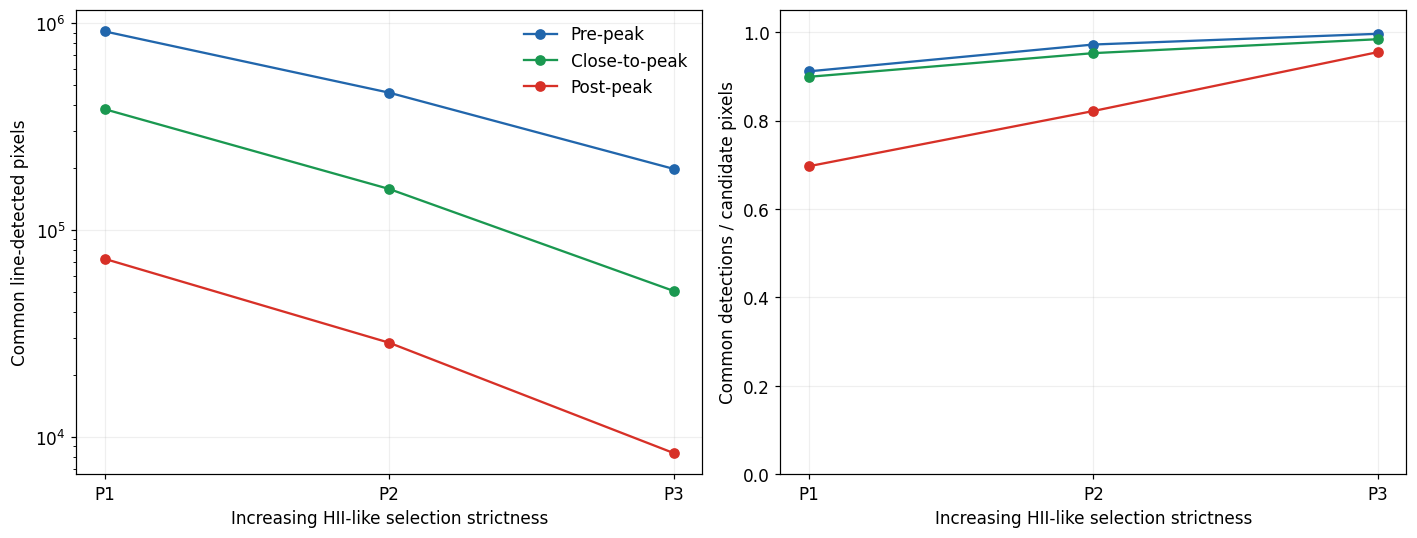

In [15]:
fig,axes=plt.subplots(1,2,figsize=(13,5))
for stage in STAGE_ORDER:
    t=SELECTION_COUNTS.loc[SELECTION_COUNTS.stage.eq(stage)].groupby('selection')[['N_candidate','N_common']].sum().reindex(PURITY_PATH)
    axes[0].plot(range(3),t.N_common,marker='o',color=STAGE_COLORS[stage],label=STAGE_LABELS[stage])
    fraction=np.divide(t.N_common,t.N_candidate,out=np.full(3,np.nan),where=t.N_candidate>0)
    axes[1].plot(range(3),fraction,marker='o',color=STAGE_COLORS[stage],label=STAGE_LABELS[stage])
for ax in axes: ax.set_xticks(range(3),['P1','P2','P3']);ax.set_xlabel('Increasing HII-like selection strictness');ax.grid(alpha=.2)
axes[0].set_yscale('log');axes[0].set_ylabel('Common line-detected pixels');axes[0].legend(frameon=False)
axes[1].set_ylabel('Common detections / candidate pixels');axes[1].set_ylim(0,1.05)
fig.tight_layout();plt.show()

### Plot: the pre-peak two-dimensional reference and common support
Blank cells are excluded. This uses P2; other grid selections are retained in `TEST2_CELLS`.

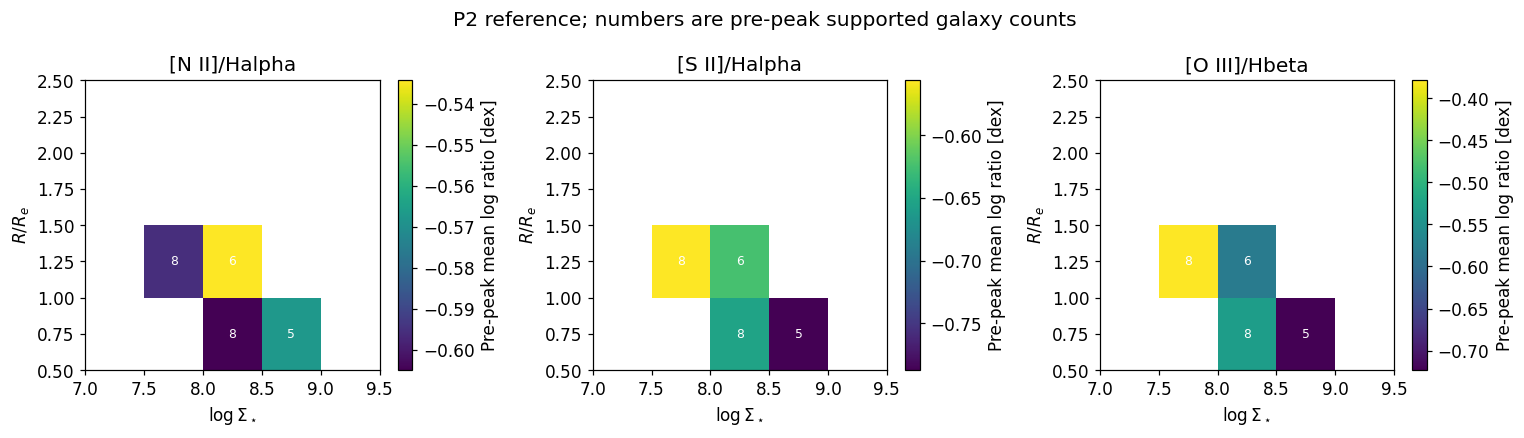

In [17]:
fig,axes=plt.subplots(1,3,figsize=(14,4))
for ax,k in zip(axes,RATIO_KEYS):
    t=TEST2_CELLS.loc[TEST2_CELLS.selection.eq(PURITY_PATH[1]) & TEST2_CELLS.stage.eq('pre-peak') & TEST2_CELLS.ratio.eq(k)]
    values=np.full(NC,np.nan)
    values[t.cell.to_numpy(int)]=np.where(t.matched,t.mean_log_ratio,np.nan)
    im=ax.pcolormesh(MASS_EDGES_2D,RADIAL_EDGES_2D,values.reshape(NM,NR).T,shading='flat',cmap='viridis')
    for row in t.loc[t.matched].itertuples():ax.text(row.mass_center,row.radius_center,str(row.N_gal),ha='center',va='center',fontsize=8,color='white')
    ax.set_title(RATIO_NAMES[k]);ax.set_xlabel(r'$\log\Sigma_\star$');ax.set_ylabel(r'$R/R_e$');fig.colorbar(im,ax=ax,label='Pre-peak mean log ratio [dex]')
fig.suptitle('P2 reference; numbers are pre-peak supported galaxy counts');fig.tight_layout();plt.show()

### Plot: stage residuals along the nested purity path
This first view uses each selection’s own three-stage matched domain. The following cell fixes the domain across P1/P2/P3 to distinguish a purity change from a changing spatial footprint.

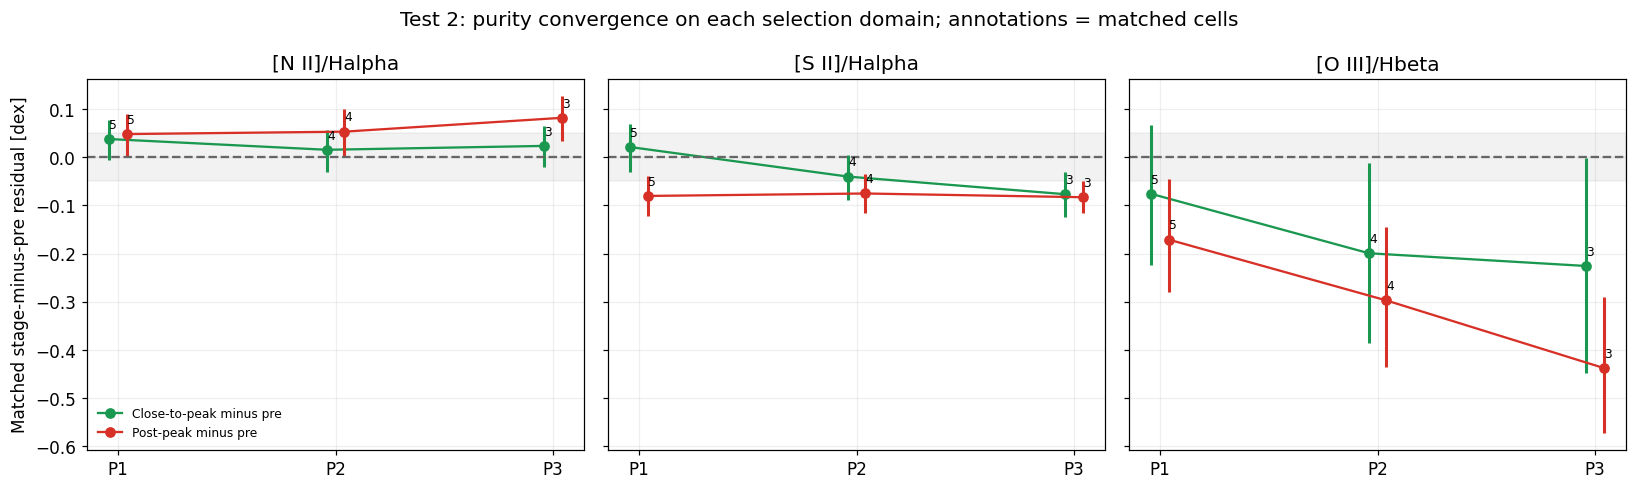

In [19]:
def plot_test2_results(results,title):
    fig,axes=plt.subplots(1,3,figsize=(15,4.5),sharey=True)
    for ax,k in zip(axes,RATIO_KEYS):
        for j,stage in enumerate(STAGE_ORDER[1:]):
            t=results.loc[results.ratio.eq(k)&results.stage.eq(stage)].set_index('selection').reindex(PURITY_PATH)
            x=np.arange(3)+(j-.5)*.08
            ax.plot(x,t.delta_dex,color=STAGE_COLORS[stage],marker='o',label=STAGE_LABELS[stage]+' minus pre')
            for xi,row in zip(x,t.itertuples()):
                if np.isfinite(row.lo):ax.vlines(xi,row.lo,row.hi,color=STAGE_COLORS[stage],lw=2)
            for xi,row in zip(x,t.itertuples()):ax.annotate(str(row.N_matched_cells),(xi,row.delta_dex),xytext=(0,7),textcoords='offset points',fontsize=8)
        ax.axhline(0,color='.4',ls='--');ax.axhspan(-TEST2_EQUIVALENCE_MARGIN_DEX,TEST2_EQUIVALENCE_MARGIN_DEX,color='.5',alpha=.1)
        ax.set_xticks(range(3),['P1','P2','P3']);ax.set_title(RATIO_NAMES[k]);ax.grid(alpha=.2)
    axes[0].set_ylabel('Matched stage-minus-pre residual [dex]');axes[0].legend(frameon=False,fontsize=8)
    fig.suptitle(title+'; annotations = matched cells');fig.tight_layout();plt.show()
plot_test2_results(TEST2_RESULTS,'Test 2: purity convergence on each selection domain')

### Plot: purity convergence on one fixed joint domain

,selection,stage,ratio,delta_dex,lo,hi,N_matched_cells,N_finite_draws
0,E12_L38.5_S45,close-to-peak,N2,0.044347,-0.000924,0.084974,3,1972
1,E12_L38.5_S45,close-to-peak,S2,-0.006615,-0.054827,0.036650,3,1972
2,E12_L38.5_S45,close-to-peak,O3,-0.066820,-0.223414,0.085469,3,1972
3,E12_L38.5_S45,post-peak,N2,0.090986,0.046768,0.133136,3,1996
4,E12_L38.5_S45,post-peak,S2,-0.078800,-0.115913,-0.041656,3,1996
5,E12_L38.5_S45,post-peak,O3,-0.168618,-0.278355,-0.044377,3,1996
6,E25_L39_S35,close-to-peak,N2,0.024454,-0.021418,0.065600,3,1972
7,E25_L39_S35,close-to-peak,S2,-0.064217,-0.106377,-0.023877,3,1972
8,E25_L39_S35,close-to-peak,O3,-0.172976,-0.362035,0.023054,3,1972
9,E25_L39_S35,post-peak,N2,0.073267,0.027249,0.116213,3,1979


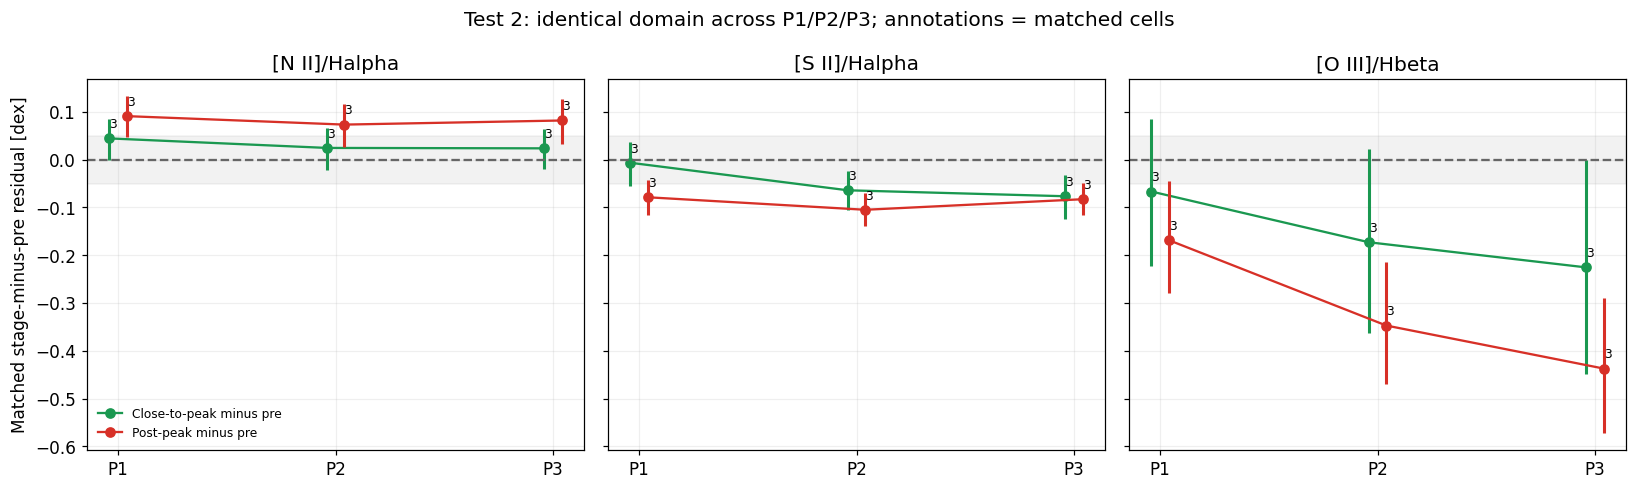

In [21]:
path_support=TEST2_CELLS.loc[TEST2_CELLS.selection.isin(PURITY_PATH)&TEST2_CELLS.ratio.eq('N2')]
common_path_cells=path_support.groupby('cell').matched.all()
FIXED_PATH_CELLS=np.flatnonzero(common_path_cells.reindex(range(NC),fill_value=False).to_numpy())
fixed_rows=[]
for selection in PURITY_PATH:
    tensors={s:np.log10(make_tensor(selection,s))[:,FIXED_PATH_CELLS,:] for s in STAGE_ORDER}
    central={s:mean_available(v,0) for s,v in tensors.items()}
    boot={s:mean_available(v[BOOT_INDICES[s]],1) for s,v in tensors.items()}
    for stage in STAGE_ORDER[1:]:
        for ki,k in enumerate(RATIO_KEYS):
            if len(FIXED_PATH_CELLS):
                delta=boot[stage][:,:,ki]-boot['pre-peak'][:,:,ki]
                draws=np.where(np.isfinite(delta).all(axis=1),mean_available(delta,1),np.nan)
                value=float((central[stage][:,ki]-central['pre-peak'][:,ki]).mean())
            else:draws=np.full(N_BOOT,np.nan);value=np.nan
            finite=draws[np.isfinite(draws)]
            lo,hi=np.percentile(finite,[16,84]) if len(finite) else (np.nan,np.nan)
            fixed_rows.append({'selection':selection,'stage':stage,'ratio':k,'delta_dex':value,'lo':lo,'hi':hi,'N_matched_cells':len(FIXED_PATH_CELLS),'N_finite_draws':len(finite)})
FIXED_PATH_RESULTS=pd.DataFrame(fixed_rows)
display(FIXED_PATH_RESULTS)
plot_test2_results(FIXED_PATH_RESULTS,'Test 2: identical domain across P1/P2/P3')

### Plot: full threshold grid and compactness/central-exclusion sensitivity
These are exploratory sensitivity comparisons, not independent hypothesis tests.

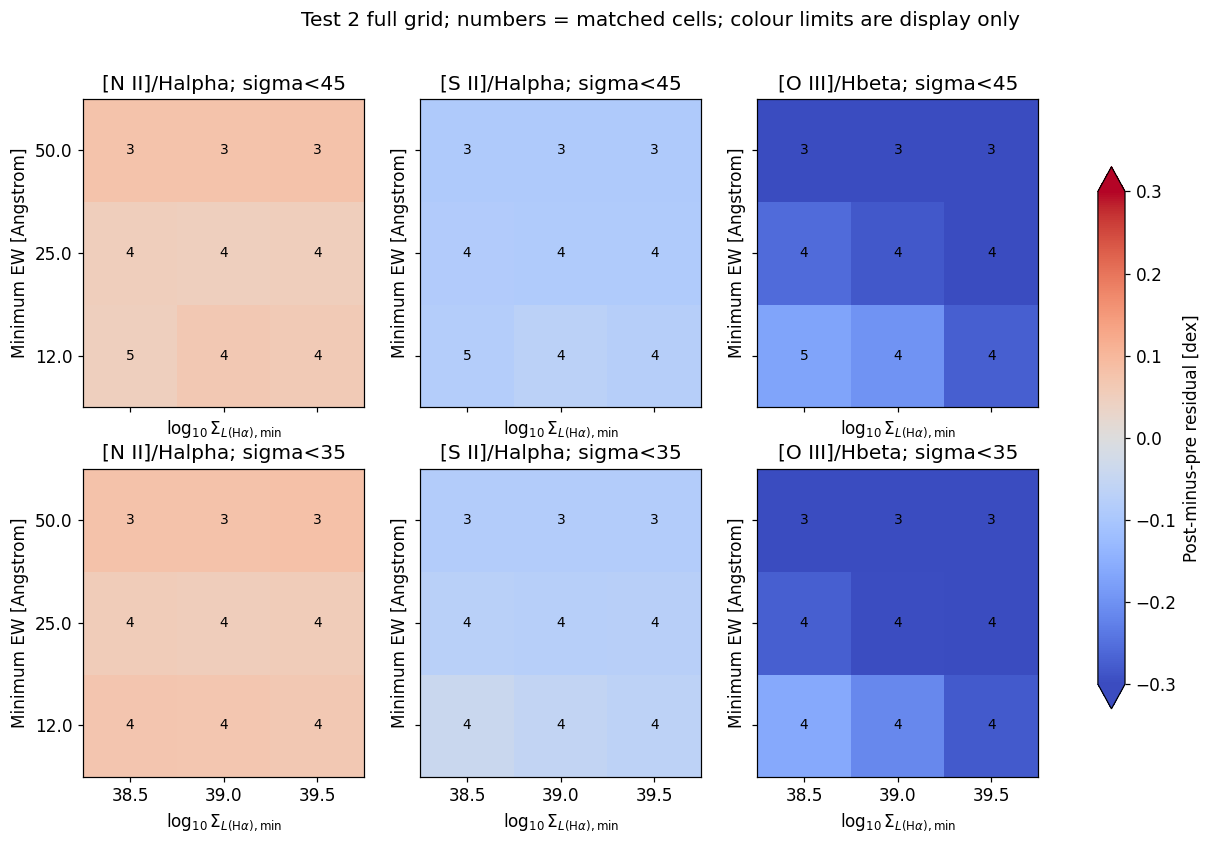

,selection,stage,ratio,N_matched_cells,N_finite_draws,delta_dex,lo,hi,status
54,E25_L39_S35,close-to-peak,N2,4,1972,0.015526,-0.029791,0.057174,inconclusive
55,E25_L39_S35,close-to-peak,S2,4,1972,-0.040065,-0.088417,0.005198,inconclusive
56,E25_L39_S35,close-to-peak,O3,4,1972,-0.199158,-0.386187,-0.011916,inconclusive
57,E25_L39_S35,post-peak,N2,4,1979,0.053130,0.003613,0.100167,inconclusive
58,E25_L39_S35,post-peak,S2,4,1979,-0.075160,-0.114961,-0.035469,inconclusive
59,E25_L39_S35,post-peak,O3,4,1979,-0.297033,-0.435777,-0.145276,offset beyond tolerance
108,P2_compact,close-to-peak,N2,4,1972,0.021246,-0.029782,0.067777,inconclusive
109,P2_compact,close-to-peak,S2,4,1972,-0.023446,-0.069058,0.018056,inconclusive
110,P2_compact,close-to-peak,O3,4,1972,-0.222538,-0.428110,-0.014271,inconclusive
111,P2_compact,post-peak,N2,4,1977,0.070724,0.014131,0.122126,inconclusive


In [23]:
fig,axes=plt.subplots(2,3,figsize=(14,8),sharex=True,sharey=True)
for ri,sig in enumerate(SIGMA_GRID):
    for ci,k in enumerate(RATIO_KEYS):
        t=TEST2_RESULTS.merge(PURITY_GRID,on='selection').loc[lambda t:t.stage.eq('post-peak')&t.ratio.eq(k)&t.sigma_max.eq(sig)&t.selection.str.startswith('E')]
        values=t.pivot(index='ew_min',columns='log_lha_min',values='delta_dex').reindex(index=EW_GRID,columns=LOG_LHA_GRID)
        im=axes[ri,ci].imshow(values,origin='lower',aspect='auto',cmap='coolwarm',vmin=-.3,vmax=.3)
        axes[ri,ci].set_xticks(range(3),LOG_LHA_GRID);axes[ri,ci].set_yticks(range(3),EW_GRID)
        axes[ri,ci].set_title(RATIO_NAMES[k]+f'; sigma<{sig:g}');axes[ri,ci].set_xlabel(r'$\log_{10}\Sigma_{L(\mathrm{H}\alpha),\min}$');axes[ri,ci].set_ylabel('Minimum EW [Angstrom]')
        for row in t.itertuples():
            axes[ri,ci].text(LOG_LHA_GRID.index(row.log_lha_min),EW_GRID.index(row.ew_min),f'{row.N_matched_cells}',ha='center',va='center',fontsize=9)
fig.colorbar(im,ax=axes.ravel().tolist(),label='Post-minus-pre residual [dex]',shrink=.8,extend='both')
fig.suptitle('Test 2 full grid; numbers = matched cells; colour limits are display only');plt.show()
display(TEST2_RESULTS.loc[TEST2_RESULTS.selection.isin([PURITY_PATH[1],'P2_compact','P2_central_0.75'])])

## Test 3: empirical endpoints and paired uncertainty

Endpoints are estimated **only from pre-peak** galaxy ratio vectors within each
joint spatial cell. The HII-like endpoint uses P3. Diffuse-like endpoints use
each brightness ceiling above. Cells need three pre-peak galaxies supporting
each endpoint and three galaxies supporting the target observation.

Galaxy resampling indices are shared between HII-like, diffuse-like and
observed pre-peak vectors; close/post observations are independently resampled.
This preserves endpoint covariance and their relation to pre-peak observations.
The same complete-galaxy draw is shared across ratios and spatial bins.
Close/post observations were not used to train endpoints. Pre-peak stage
fits reuse training galaxies and are descriptive; a separate leave-one-galaxy-out
view below evaluates pre-peak observations with independent endpoints.

Weights are computed separately from each ratio without clipping. A coordinate
is flagged weakly identified if the central endpoint separation is below 10%
of their scale or its bootstrap interval includes zero. Such cells are excluded
from the primary all-three-ratio fit, not silently assigned stable fractions.

The joint fit uses the covariance of bootstrap residual vectors at $w=0.5$,
including observations and both endpoints. A small numerical ridge is reported.
It is a fixed-covariance diagnostic, not a calibrated chi-square likelihood;
no p-values are reported. A bounded common weight is fitted, with per-ratio
residuals and leave-one-ratio-out predictions. Endpoint uncertainty is propagated
through each bootstrap fit using that same covariance metric.

In [25]:
def covariance_metric(residual_draws):
    valid=residual_draws[np.isfinite(residual_draws).all(axis=1)]
    if len(valid)<100:return None,0,np.nan
    cov=np.cov(valid,rowvar=False)
    scale=max(float(np.trace(cov)/3),1e-8)
    ridge=scale*1e-4
    return np.linalg.inv(cov+ridge*np.eye(3)),int(np.linalg.matrix_rank(cov)),ridge

def joint_weight(observed,hii,diffuse,metric):
    direction=diffuse-hii
    numerator=np.einsum('...i,ij,...j->...',direction,metric,observed-hii)
    denominator=np.einsum('...i,ij,...j->...',direction,metric,direction)
    unbounded=np.divide(numerator,denominator,out=np.full(np.shape(numerator),np.nan),where=denominator>0)
    return np.clip(unbounded,0,1)

def interval(values):
    finite=np.asarray(values)[np.isfinite(values)]
    return tuple(np.percentile(finite,[16,84])) if len(finite) else (np.nan,np.nan)

MIX_ROWS,MIX_DIAGNOSTICS,MIX_DRAWS=[],[],{}
for ceiling in DIG_LOG_LHA_MAX_GRID:
    dsel=f'DIG_L{ceiling:g}'
    H=make_tensor(HII_ENDPOINT_SELECTION,'pre-peak',(*RATIO_KEYS,'Balmer'))
    D=make_tensor(dsel,'pre-peak',(*RATIO_KEYS,'Balmer'))
    hc,dc=mean_available(H,0),mean_available(D,0)
    hb,db=mean_available(H[BOOT_INDICES['pre-peak']],1),mean_available(D[BOOT_INDICES['pre-peak']],1)
    support_h=np.isfinite(H[:,:,0]).sum(axis=0);support_d=np.isfinite(D[:,:,0]).sum(axis=0)
    for stage in STAGE_ORDER:
        O=make_tensor('all_detected',stage,(*RATIO_KEYS,'Balmer'))
        oc=mean_available(O,0);ob=mean_available(O[BOOT_INDICES[stage]],1)
        support_o=np.isfinite(O[:,:,0]).sum(axis=0)
        for ci in range(NC):
            enough=min(support_h[ci],support_d[ci],support_o[ci])>=MIN_GAL
            gap=dc[ci,:3]-hc[ci,:3]
            rel=np.abs(gap)/np.maximum(np.maximum(np.abs(hc[ci,:3]),np.abs(dc[ci,:3])),1e-12)
            gap_bounds=np.array([interval(db[:,ci,k]-hb[:,ci,k]) for k in range(3)])
            stable=(rel >= MIN_ENDPOINT_REL_SEPARATION)&((gap_bounds[:,0]>0)|(gap_bounds[:,1]<0))
            balmer_equal=bool(np.isfinite(hc[ci,3]) and np.isfinite(dc[ci,3]) and abs(hc[ci,3]/dc[ci,3]-1)<BALMER_REL_TOL)
            status='eligible' if enough and stable.all() and balmer_equal else ('insufficient support' if not enough else 'unequal corrected Balmer endpoints' if not balmer_equal else 'weak endpoint separation')
            diagnostic={'DIG_selection':dsel,'stage':stage,'cell':ci,'N_HII_gal':int(support_h[ci]),'N_DIG_gal':int(support_d[ci]),'N_obs_gal':int(support_o[ci]),'status':status,'H_Balmer':hc[ci,3],'D_Balmer':dc[ci,3]}
            for k,key in enumerate(RATIO_KEYS):diagnostic['gap_'+key]=gap[k];diagnostic['identified_'+key]=bool(stable[k])
            MIX_DIAGNOSTICS.append(diagnostic)
            if not enough:continue
            w=np.divide(oc[ci,:3]-hc[ci,:3],gap,out=np.full(3,np.nan),where=np.abs(gap)>1e-12)
            wd=np.divide(ob[:,ci,:3]-hb[:,ci,:3],db[:,ci,:3]-hb[:,ci,:3],out=np.full((N_BOOT,3),np.nan),where=np.abs(db[:,ci,:3]-hb[:,ci,:3])>1e-12)
            metric,rank,ridge=covariance_metric(ob[:,ci,:3]-.5*(hb[:,ci,:3]+db[:,ci,:3]))
            eligible=status=='eligible' and metric is not None
            joint=float(joint_weight(oc[ci,:3],hc[ci,:3],dc[ci,:3],metric)) if eligible else np.nan
            boot_joint=joint_weight(ob[:,ci,:3],hb[:,ci,:3],db[:,ci,:3],metric) if eligible else np.full(N_BOOT,np.nan)
            pred=hc[ci,:3]+joint*gap
            joint_bounds=interval(boot_joint)
            rec={**diagnostic,'joint_w':joint,'joint_lo':joint_bounds[0],'joint_hi':joint_bounds[1],
                 'covariance_rank':rank,'covariance_ridge':ridge,'N_joint_draws':int(np.isfinite(boot_joint).sum())}
            for k,key in enumerate(RATIO_KEYS):
                lo,hi=interval(wd[:,k])
                rec['w_'+key]=w[k];rec['w_'+key+'_lo']=lo;rec['w_'+key+'_hi']=hi
                rec['observed_'+key]=oc[ci,k];rec['H_'+key]=hc[ci,k];rec['D_'+key]=dc[ci,k];rec['predicted_'+key]=pred[k]
                rec['residual_'+key+'_dex']=np.log10(oc[ci,k]/pred[k]) if pred[k]>0 else np.nan
                keep=[j for j in range(3) if j!=k]
                if eligible:
                    m=np.linalg.inv(np.linalg.inv(metric)[np.ix_(keep,keep)])
                    wi=float(joint_weight(oc[ci,keep],hc[ci,keep],dc[ci,keep],m))
                    wi_boot=joint_weight(ob[:,ci,keep],hb[:,ci,keep],db[:,ci,keep],m)
                    held=hc[ci,k]+wi*gap[k]
                    held_draw=hb[:,ci,k]+wi_boot*(db[:,ci,k]-hb[:,ci,k])
                    residual=np.log10(ob[:,ci,k]/held_draw)
                    rlo,rhi=interval(residual)
                    rec['heldout_'+key+'_dex']=np.log10(oc[ci,k]/held)
                    rec['heldout_'+key+'_lo']=rlo;rec['heldout_'+key+'_hi']=rhi
                else:rec['heldout_'+key+'_dex']=np.nan;rec['heldout_'+key+'_lo']=np.nan;rec['heldout_'+key+'_hi']=np.nan
            MIX_ROWS.append(rec)
            MIX_DRAWS[(dsel,stage,ci)]={'weights':wd,'joint':boot_joint}
MIX_RESULTS=pd.DataFrame(MIX_ROWS).merge(CELL_GEOMETRY,on='cell')
ENDPOINT_QC=pd.DataFrame(MIX_DIAGNOSTICS).merge(CELL_GEOMETRY,on='cell')
display(ENDPOINT_QC.groupby(['DIG_selection','stage','status']).size().rename('N_cells'))
display(MIX_RESULTS)

DIG_selection  stage          status                            
DIG_L38.5      close-to-peak  eligible                               2
                              insufficient support                  14
                              unequal corrected Balmer endpoints     1
                              weak endpoint separation               3
               post-peak      eligible                               2
                              insufficient support                  15
                              unequal corrected Balmer endpoints     1
                              weak endpoint separation               2
               pre-peak       eligible                               2
                              insufficient support                  14
                              unequal corrected Balmer endpoints     1
                              weak endpoint separation               3
DIG_L39        close-to-peak  eligible                               2
            

,DIG_selection,stage,cell,N_HII_gal,N_DIG_gal,N_obs_gal,status,H_Balmer,D_Balmer,gap_N2,identified_N2,gap_S2,identified_S2,gap_O3,identified_O3,joint_w,joint_lo,joint_hi,covariance_rank,covariance_ridge,N_joint_draws,w_N2,w_N2_lo,w_N2_hi,observed_N2,H_N2,D_N2,predicted_N2,residual_N2_dex,heldout_N2_dex,heldout_N2_lo,heldout_N2_hi,w_S2,w_S2_lo,w_S2_hi,observed_S2,H_S2,D_S2,predicted_S2,residual_S2_dex,heldout_S2_dex,heldout_S2_lo,heldout_S2_hi,w_O3,w_O3_lo,w_O3_hi,observed_O3,H_O3,D_O3,predicted_O3,residual_O3_dex,heldout_O3_dex,heldout_O3_lo,heldout_O3_hi,mass_center,radius_center
0,DIG_L38.5,pre-peak,1,4,4,6,weak endpoint separation,2.86,2.859943,0.104274,True,0.374081,True,0.091162,False,NaN,NaN,NaN,3,2.909250e-07,0,0.447073,0.183968,0.619077,0.300524,0.253906,0.358180,NaN,NaN,NaN,NaN,NaN,0.333006,0.243757,0.430327,0.358511,0.233940,0.608021,NaN,NaN,NaN,NaN,NaN,-1.152309,-0.539208,1.595201,0.535875,0.640921,0.732083,NaN,NaN,NaN,NaN,NaN,7.25,1.25
1,DIG_L38.5,pre-peak,4,7,5,7,eligible,2.86,2.859384,0.147711,True,0.348917,True,0.229476,True,0.241138,0.217733,0.263236,3,7.681380e-08,1998,0.254050,0.210520,0.319872,0.301544,0.264018,0.411729,0.299637,0.002756,0.007245,-0.005427,0.019865,0.228087,0.199099,0.257583,0.304898,0.225314,0.574231,0.309451,-0.006438,0.011789,-0.011827,0.030258,0.102611,-0.018692,0.200163,0.459564,0.436017,0.665493,0.491352,-0.029047,-0.027669,-0.040503,-0.014608,7.75,0.75
2,DIG_L38.5,pre-peak,5,8,6,8,weak endpoint separation,2.86,2.859283,0.176548,True,0.330802,True,0.208161,False,NaN,NaN,NaN,3,2.086228e-07,0,0.131024,0.103993,0.169366,0.285405,0.262273,0.438821,NaN,NaN,NaN,NaN,NaN,0.188270,0.164334,0.211248,0.322825,0.260545,0.591347,NaN,NaN,NaN,NaN,NaN,0.011239,-0.088284,0.283250,0.629418,0.627078,0.835240,NaN,NaN,NaN,NaN,NaN,7.75,1.25
3,DIG_L38.5,pre-peak,6,5,3,6,eligible,2.86,2.859594,0.161141,True,0.319591,True,0.367506,True,0.255904,0.199269,0.307605,3,5.750885e-07,1952,-0.018331,-0.166695,0.197554,0.279568,0.282522,0.443664,0.323759,-0.063734,-0.059894,-0.101351,-0.011041,0.253698,0.191247,0.314080,0.330996,0.249916,0.569507,0.331701,-0.000924,0.023617,0.007049,0.038706,0.444937,0.088580,0.754626,0.638118,0.474601,0.842107,0.568648,0.050058,0.051314,-0.035448,0.115440,7.75,1.75
4,DIG_L38.5,pre-peak,8,8,5,8,weak endpoint separation,2.86,2.859135,0.250654,True,0.347457,True,0.032199,False,NaN,NaN,NaN,3,2.402819e-07,0,0.097156,0.078750,0.120047,0.279560,0.255207,0.505861,NaN,NaN,NaN,NaN,NaN,0.138832,0.112340,0.170670,0.263345,0.215107,0.562564,NaN,NaN,NaN,NaN,NaN,0.245621,-0.010574,0.251438,0.525513,0.517604,0.549803,NaN,NaN,NaN,NaN,NaN,8.25,0.75
5,DIG_L38.5,pre-peak,9,6,3,6,unequal corrected Balmer endpoints,2.86,2.852871,0.270801,True,0.302600,True,0.189138,True,NaN,NaN,NaN,3,1.087554e-07,0,0.061707,0.031418,0.091247,0.313089,0.296379,0.567180,NaN,NaN,NaN,NaN,NaN,0.122459,0.081052,0.167066,0.266824,0.229768,0.532368,NaN,NaN,NaN,NaN,NaN,0.009884,-0.100192,0.139814,0.362126,0.360256,0.549394,NaN,NaN,NaN,NaN,NaN,8.25,1.25
6,DIG_L38.5,close-to-peak,1,4,4,3,weak endpoint separation,2.86,2.859943,0.104274,True,0.374081,True,0.091162,False,NaN,NaN,NaN,3,2.832051e-06,0,0.691095,0.023865,1.532929,0.325969,0.253906,0.358180,NaN,NaN,NaN,NaN,NaN,0.410762,0.200032,0.622207,0.387599,0.233940,0.608021,NaN,NaN,NaN,NaN,NaN,-0.895488,-0.214392,2.089144,0.559287,0.640921,0.732083,NaN,NaN,NaN,NaN,NaN,7.25,1.25
7,DIG_L38.5,close-to-peak,4,7,5,3,eligible,2.86,2.859384,0.147711,True,0.348917,True,0.229476,True,0.713403,0.278422,0.843388,3,1.607927e-06,1974,0.676797,0.246305,1.307580,0.363989,0.264018,0.411729,0.369396,-0.006404,0.001267,-0.048742,0.064276,0.482612,0.166947,0.826102,0.393706,0.225314,0.574231,0.474232,-0.080820,0.011924,-0.081686,0.086071,-0.235966,-1.282770,0.765551,0.381868,0.436017,0.665493,0.599726,-0.196039,-0.157670,-0.295365,0.000412,7.75,0.75
8,DIG_L38.5,close-to-peak,5,8,6,5,weak endpoint separation,2.86,2.859283,0.176548,True,0.330802,True,0.208161,False,NaN,NaN,NaN,3,2.349911e-06,0,0.904758,0.4

### Plot: independent weights from N2, S2 and O3
Weights outside [0, 1] remain visible. Weakly separated coordinates are recorded in the tables but omitted from this primary all-three-ratio comparison.

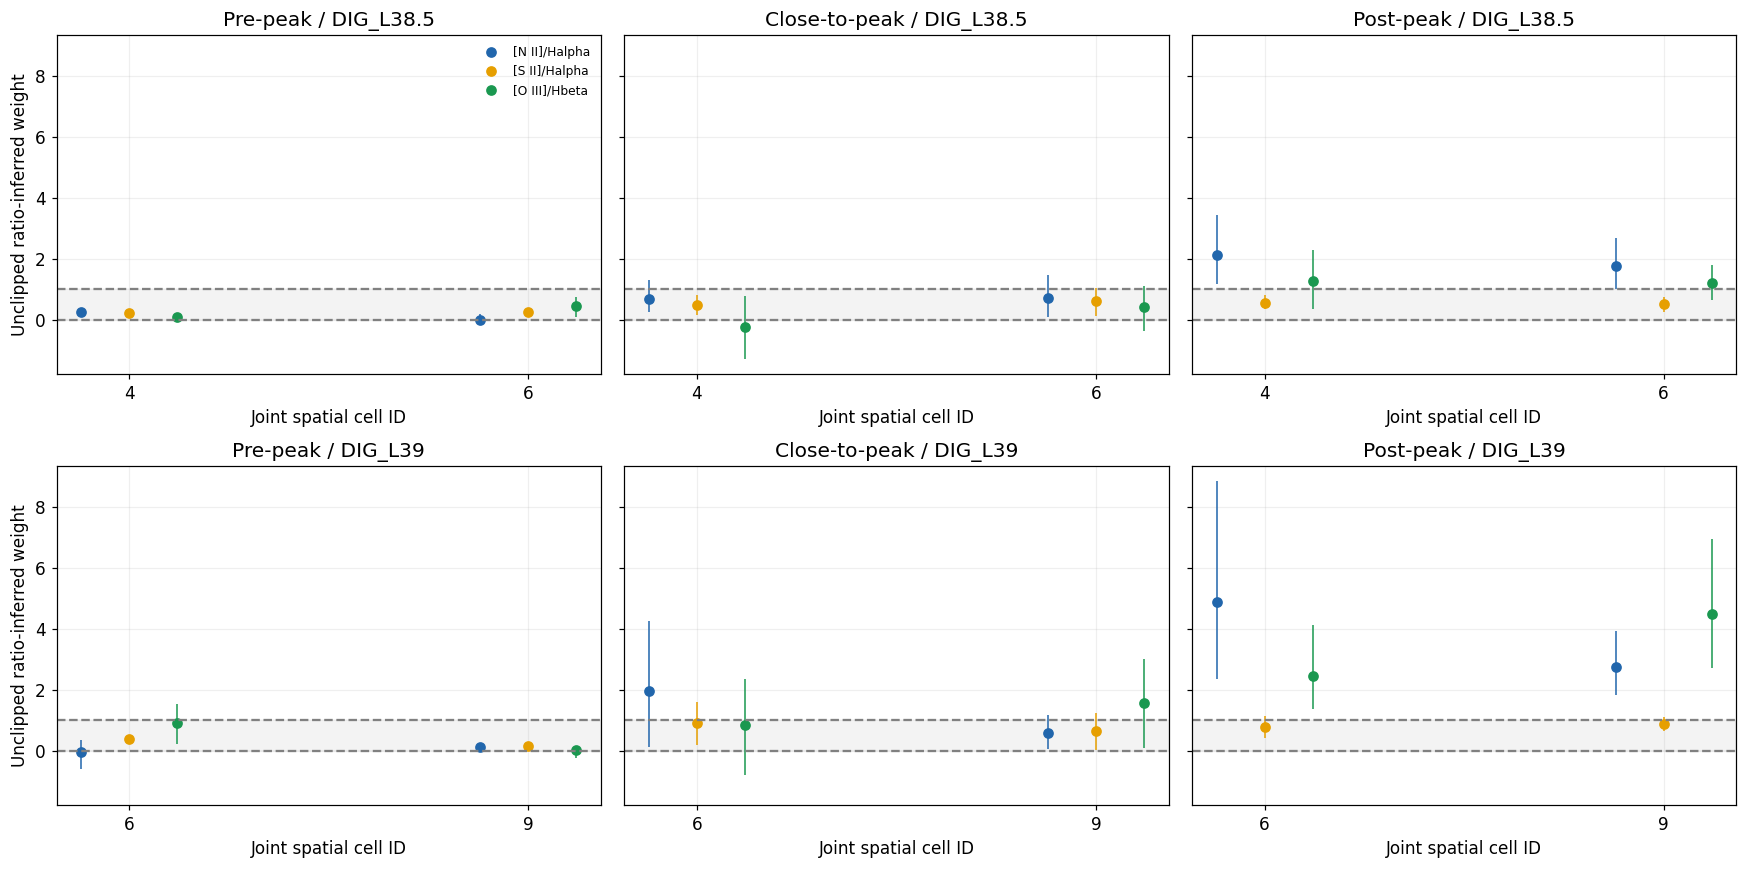

In [27]:
fig,axes=plt.subplots(2,3,figsize=(16,8),sharey=True)
for ri,dsel in enumerate([f'DIG_L{x:g}' for x in DIG_LOG_LHA_MAX_GRID]):
    for ci,stage in enumerate(STAGE_ORDER):
        ax=axes[ri,ci]
        t=MIX_RESULTS.loc[MIX_RESULTS.DIG_selection.eq(dsel)&MIX_RESULTS.stage.eq(stage)&MIX_RESULTS.status.eq('eligible')].sort_values('cell')
        for j,key in enumerate(RATIO_KEYS):
            x=np.arange(len(t))+(j-1)*.12
            color=('#2166ac','#e69f00','#1a9850')[j]
            ax.plot(x,t['w_'+key],marker='o',ls='none',color=color,label=RATIO_NAMES[key])
            for xi,row in zip(x,t.itertuples()):ax.vlines(xi,getattr(row,'w_'+key+'_lo'),getattr(row,'w_'+key+'_hi'),lw=1,color=color)
        ax.axhspan(0,1,color='.7',alpha=.15);ax.axhline(0,color='.5',ls='--');ax.axhline(1,color='.5',ls='--')
        ax.set_title(STAGE_LABELS[stage]+' / '+dsel);ax.set_xticks(range(len(t)),t.cell.astype(str));ax.set_xlabel('Joint spatial cell ID');ax.grid(alpha=.2)
        if len(t)==0:ax.text(.5,.5,'No identified cells',transform=ax.transAxes,ha='center')
axes[0,0].set_ylabel('Unclipped ratio-inferred weight');axes[1,0].set_ylabel('Unclipped ratio-inferred weight');axes[0,0].legend(fontsize=8,frameon=False)
fig.tight_layout();plt.show()

### Plot: bounded joint weight and spectral residuals
A bounded fit can return 0 or 1 even when the fixed endpoints do not explain the spectrum. Read the residuals with the fitted weights.

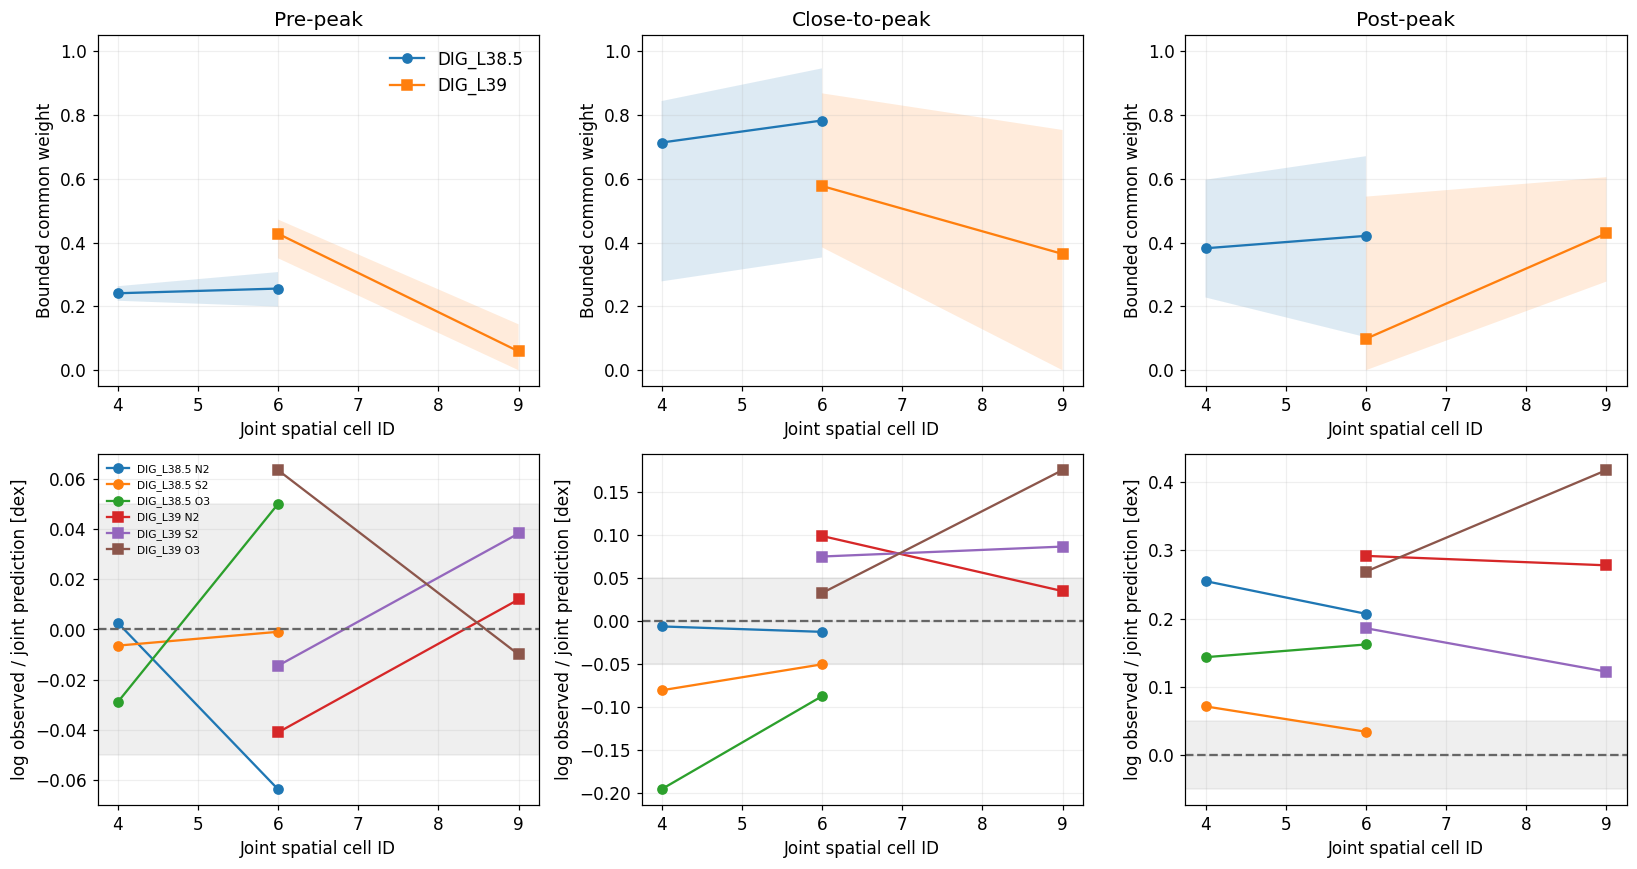

In [29]:
fig,axes=plt.subplots(2,3,figsize=(15,8))
for ci,stage in enumerate(STAGE_ORDER):
    for dsel,marker in zip([f'DIG_L{x:g}' for x in DIG_LOG_LHA_MAX_GRID],('o','s')):
        t=MIX_RESULTS.loc[MIX_RESULTS.stage.eq(stage)&MIX_RESULTS.DIG_selection.eq(dsel)&MIX_RESULTS.status.eq('eligible')].sort_values('cell')
        axes[0,ci].plot(t.cell,t.joint_w,marker=marker,label=dsel)
        axes[0,ci].fill_between(t.cell.to_numpy(float),t.joint_lo.to_numpy(float),t.joint_hi.to_numpy(float),alpha=.15)
        for k in RATIO_KEYS:axes[1,ci].plot(t.cell,t['residual_'+k+'_dex'],marker=marker,label=dsel+' '+k)
    axes[0,ci].set_ylim(-.05,1.05);axes[0,ci].set_title(STAGE_LABELS[stage]);axes[0,ci].set_ylabel('Bounded common weight')
    axes[1,ci].axhline(0,color='.4',ls='--');axes[1,ci].axhspan(-JOINT_RESIDUAL_TOL_DEX,JOINT_RESIDUAL_TOL_DEX,color='.7',alpha=.2);axes[1,ci].set_ylabel('log observed / joint prediction [dex]')
    for ax in axes[:,ci]:ax.set_xlabel('Joint spatial cell ID');ax.grid(alpha=.2)
axes[0,0].legend(frameon=False);axes[1,0].legend(frameon=False,fontsize=7)
fig.tight_layout();plt.show()

### Plot: predict a held-out ratio using the other two
This is more informative than judging only the in-fit residuals. Endpoint uncertainty is included; the tolerance is descriptive.

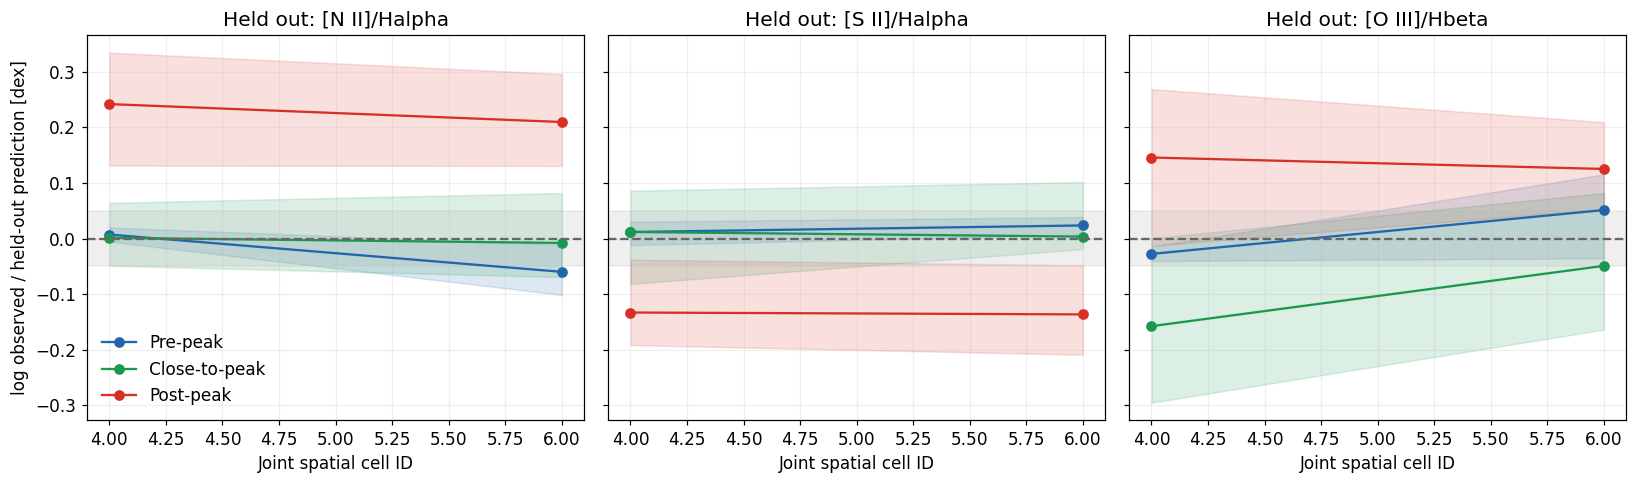

In [31]:
fig,axes=plt.subplots(1,3,figsize=(15,4.5),sharey=True)
for ax,k in zip(axes,RATIO_KEYS):
    for stage in STAGE_ORDER:
        t=MIX_RESULTS.loc[MIX_RESULTS.stage.eq(stage)&MIX_RESULTS.DIG_selection.eq('DIG_L38.5')&MIX_RESULTS.status.eq('eligible')].sort_values('cell')
        ax.plot(t.cell,t['heldout_'+k+'_dex'],marker='o',color=STAGE_COLORS[stage],label=STAGE_LABELS[stage])
        ax.fill_between(t.cell.to_numpy(float),t['heldout_'+k+'_lo'].to_numpy(float),t['heldout_'+k+'_hi'].to_numpy(float),color=STAGE_COLORS[stage],alpha=.15)
    ax.axhline(0,color='.4',ls='--');ax.axhspan(-JOINT_RESIDUAL_TOL_DEX,JOINT_RESIDUAL_TOL_DEX,color='.7',alpha=.2);ax.set_title('Held out: '+RATIO_NAMES[k]);ax.set_xlabel('Joint spatial cell ID');ax.grid(alpha=.2)
axes[0].set_ylabel('log observed / held-out prediction [dex]');axes[0].legend(frameon=False)
fig.tight_layout();plt.show()

### Plot: mixing geometry in linear ratio space

Each joint spatial cell has its own endpoints; therefore the model predicts
one common segment **within that cell**, not one global segment across different
metallicities/radii. Representative cells are selected by endpoint/observation
support, not by how well they fit. Lines show the HII-like to diffuse-like segment;
points show the three stage observations.

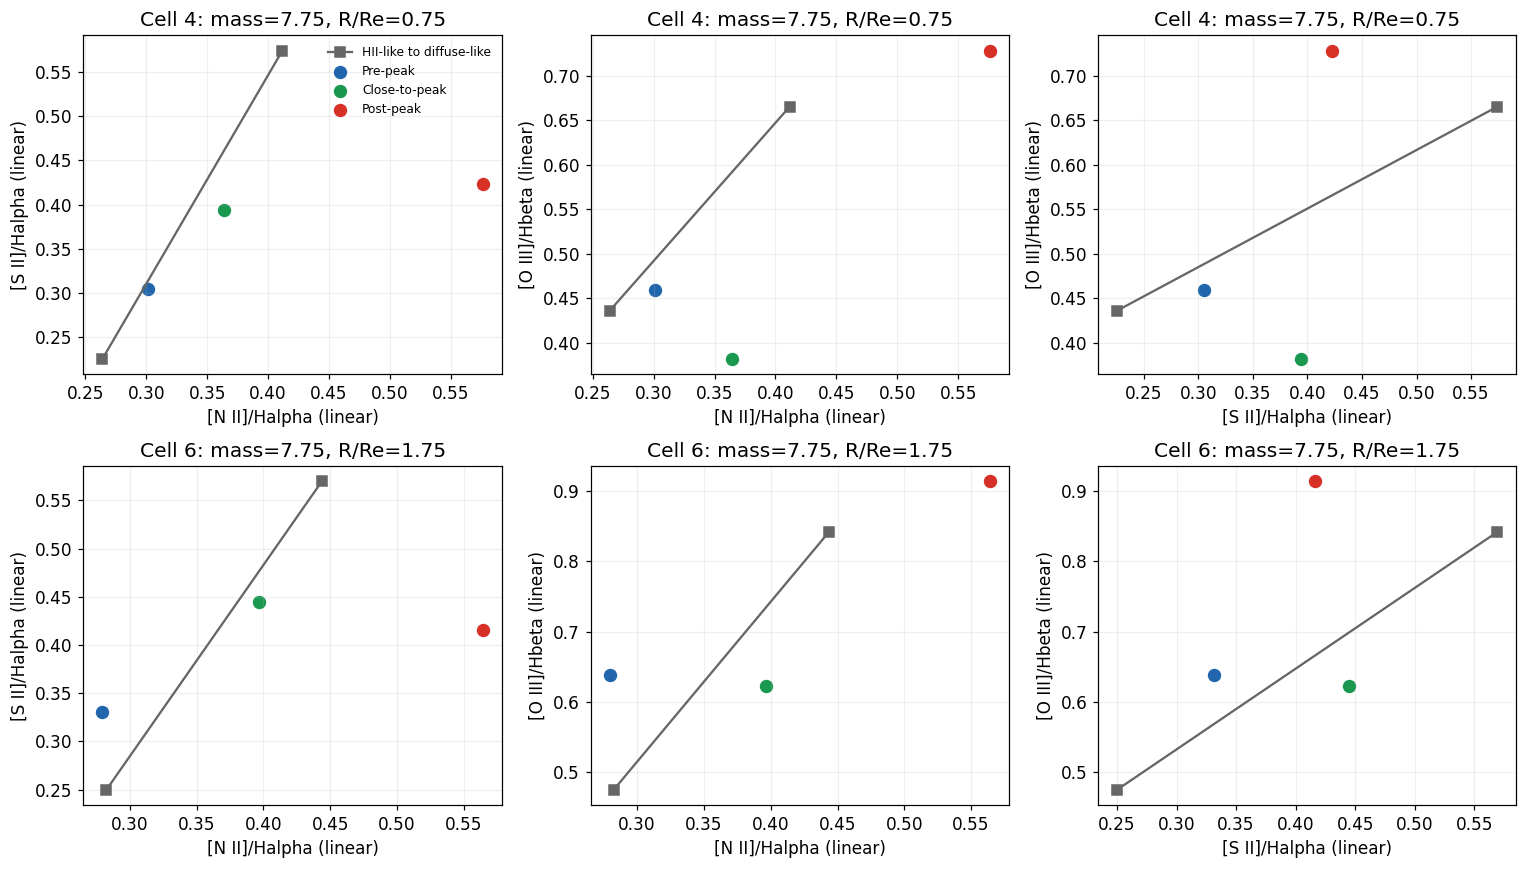

In [33]:
good=ENDPOINT_QC.loc[ENDPOINT_QC.DIG_selection.eq('DIG_L38.5')&ENDPOINT_QC.status.eq('eligible')]
representative=good.groupby('cell').stage.nunique().sort_values(ascending=False).index[:3].tolist()
fig,axes=plt.subplots(max(1,len(representative)),3,figsize=(14,4*max(1,len(representative))),squeeze=False)
for ri,cell in enumerate(representative):
    t=MIX_RESULTS.loc[MIX_RESULTS.cell.eq(cell)&MIX_RESULTS.DIG_selection.eq('DIG_L38.5')&MIX_RESULTS.status.eq('eligible')]
    endpoint=t.iloc[0]
    for ci,(kx,ky) in enumerate((('N2','S2'),('N2','O3'),('S2','O3'))):
        ax=axes[ri,ci]
        ax.plot([endpoint['H_'+kx],endpoint['D_'+kx]],[endpoint['H_'+ky],endpoint['D_'+ky]],color='.4',marker='s',label='HII-like to diffuse-like')
        for row in t.itertuples():ax.scatter(getattr(row,'observed_'+kx),getattr(row,'observed_'+ky),color=STAGE_COLORS[row.stage],s=60,label=STAGE_LABELS[row.stage])
        ax.set_xlabel(RATIO_NAMES[kx]+' (linear)');ax.set_ylabel(RATIO_NAMES[ky]+' (linear)');ax.set_title(f'Cell {cell}: mass={endpoint.mass_center:g}, R/Re={endpoint.radius_center:g}');ax.grid(alpha=.2)
if not representative:axes[0,0].text(.5,.5,'No identified endpoint cells',transform=axes[0,0].transAxes,ha='center')
else:axes[0,0].legend(frameon=False,fontsize=8)
fig.tight_layout();plt.show()

## Galaxy-level check: cross-fitted pre-peak endpoints and ancillary classes

For each observed galaxy/spatial cell, pre-peak endpoints exclude that same
galaxy. Close/post endpoints use all pre-peak galaxies. At least three other
galaxies per endpoint are required. These central fits use relative-ratio
least squares (each coordinate scaled by the midpoint endpoint magnitude),
not the stage bootstrap covariance above. Their weight distributions are a
sensitivity diagnostic, not a calibrated physical DIG-fraction measurement.

Each galaxy receives one median fitted weight across supported cells. Subsequent
stage intervals resample those galaxies. The SF fraction is measured after the
fit and does not select observations or endpoints. Proxy comparisons cannot
independently prove DIG: EW/brightness already helped define the templates.

In [35]:
GALAXY_FIT_ROWS=[]
observations=MEASUREMENTS.loc[MEASUREMENTS.selection.eq('all_detected') & MEASUREMENTS.supported]
for dsel in [f'DIG_L{x:g}' for x in DIG_LOG_LHA_MAX_GRID]:
    hi=MEASUREMENTS.loc[MEASUREMENTS.selection.eq(HII_ENDPOINT_SELECTION)&MEASUREMENTS.stage.eq('pre-peak')&MEASUREMENTS.supported]
    di=MEASUREMENTS.loc[MEASUREMENTS.selection.eq(dsel)&MEASUREMENTS.stage.eq('pre-peak')&MEASUREMENTS.supported]
    for row in observations.itertuples():
        h=hi.loc[hi.cell.eq(row.cell)&hi.GALID.ne(row.GALID)]
        d=di.loc[di.cell.eq(row.cell)&di.GALID.ne(row.GALID)]
        if min(len(h),len(d)) < MIN_GAL:continue
        H=h[list(RATIO_KEYS)].mean().to_numpy();D=d[list(RATIO_KEYS)].mean().to_numpy();O=np.array([getattr(row,k) for k in RATIO_KEYS])
        B_H=h.Balmer.mean();B_D=d.Balmer.mean()
        scale=np.maximum((H+D)/2,1e-8)
        if abs(B_H/B_D-1)>=BALMER_REL_TOL or (np.abs(D-H)/np.maximum(np.maximum(H,D),1e-8)<MIN_ENDPOINT_REL_SEPARATION).any():continue
        metric=np.diag(1/scale**2)
        w=float(joint_weight(O,H,D,metric));pred=H+w*(D-H)
        rec={'GALID':row.GALID,'stage':row.stage,'cell':row.cell,'DIG_selection':dsel,'joint_w':w,'f_SF':row.f_SF,
             'median_log_lha':row.median_log_lha,'median_EW':row.median_EW,'median_sigma':row.median_sigma,
             'median_peak_distance':row.median_peak_distance,'max_abs_residual_dex':float(np.abs(np.log10(O/pred)).max())}
        for i,k in enumerate(RATIO_KEYS):rec['w_'+k]=(O[i]-H[i])/(D[i]-H[i])
        # Forward line predictions use the measured Balmer sums explicitly.
        for k,num,den,ratio in zip(RATIO_KEYS,RATIO_NUMERATORS,RATIO_DENOMINATORS,pred):
            rec['observed_line_'+k]=getattr(row,'sum_'+num)
            rec['predicted_line_'+k]=getattr(row,'sum_'+den)*ratio
        GALAXY_FIT_ROWS.append(rec)
GALAXY_CELL_FITS=pd.DataFrame(GALAXY_FIT_ROWS)
if not GALAXY_CELL_FITS.empty:
    GALAXY_WEIGHTS=GALAXY_CELL_FITS.groupby(['DIG_selection','stage','GALID']).agg(joint_w=('joint_w','median'),N_cells=('cell','nunique'),max_residual_dex=('max_abs_residual_dex','median')).reset_index()
else:GALAXY_WEIGHTS=pd.DataFrame(columns=['DIG_selection','stage','GALID','joint_w','N_cells','max_residual_dex'])
display(GALAXY_WEIGHTS)

,DIG_selection,stage,GALID,joint_w,N_cells,max_residual_dex
0,DIG_L38.5,close-to-peak,NGC4298,0.000000,4,0.460999
1,DIG_L38.5,close-to-peak,NGC4424,1.000000,3,0.086425
2,DIG_L38.5,close-to-peak,NGC4501,0.026568,2,0.344867
3,DIG_L38.5,close-to-peak,NGC4654,0.246120,4,0.070461
4,DIG_L38.5,close-to-peak,NGC4694,1.000000,2,0.213460
5,DIG_L38.5,post-peak,IC3392,0.500000,2,0.264729
6,DIG_L38.5,post-peak,NGC4064,1.000000,3,0.250308
7,DIG_L38.5,post-peak,NGC4293,1.000000,1,0.554509
8,DIG_L38.5,post-peak,NGC4380,0.060989,2,0.250146
9,DIG_L38.5,post-peak,NGC4394,0.007570,2,0.457303


### Plot: galaxy weight distributions by stage
Pre-peak points use leave-one-galaxy-out endpoints. Stage summaries give every galaxy one vote. Different galaxy cell coverage remains a limitation; compare these with the cell-matched stage fits above.

,DIG_selection,stage,N_gal,median_w,lo,hi
0,DIG_L38.5,pre-peak,8,0.140078,0.048638,0.391609
1,DIG_L38.5,close-to-peak,5,0.246120,0.026568,1.000000
2,DIG_L38.5,post-peak,13,0.705982,0.500000,0.984011
3,DIG_L39,pre-peak,8,0.273852,0.222870,0.557963
4,DIG_L39,close-to-peak,5,0.393185,0.069759,1.000000
5,DIG_L39,post-peak,13,1.000000,0.857062,1.000000


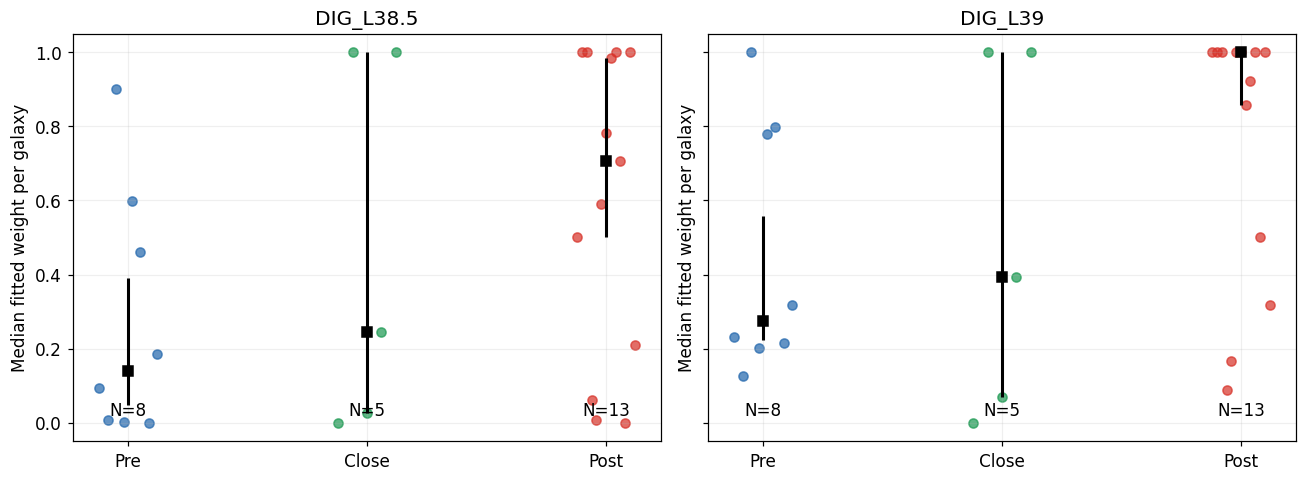

In [37]:
fig,axes=plt.subplots(1,2,figsize=(12,4.5),sharey=True)
WEIGHT_STAGE_ROWS=[]
for ax,dsel in zip(axes,[f'DIG_L{x:g}' for x in DIG_LOG_LHA_MAX_GRID]):
    for si,stage in enumerate(STAGE_ORDER):
        t=GALAXY_WEIGHTS.loc[GALAXY_WEIGHTS.DIG_selection.eq(dsel)&GALAXY_WEIGHTS.stage.eq(stage)]
        y=t.joint_w.to_numpy(float)
        ax.scatter(si+np.linspace(-.12,.12,len(y)),y,color=STAGE_COLORS[stage],alpha=.7)
        if len(y)>=MIN_GAL:
            draws=np.median(y[np.random.default_rng(RANDOM_SEED+23000+si).integers(0,len(y),size=(N_BOOT,len(y)))],axis=1)
            lo,hi=interval(draws);value=np.median(y)
            ax.plot(si,value,'ks',ms=7);ax.vlines(si,lo,hi,color='k',lw=2)
            WEIGHT_STAGE_ROWS.append({'DIG_selection':dsel,'stage':stage,'N_gal':len(y),'median_w':value,'lo':lo,'hi':hi})
        ax.text(si,.02,f'N={len(y)}',ha='center')
    ax.set_xticks(range(3),['Pre','Close','Post']);ax.set_ylim(-.05,1.05);ax.set_title(dsel);ax.set_ylabel('Median fitted weight per galaxy');ax.grid(alpha=.2)
WEIGHT_STAGE_SUMMARY=pd.DataFrame(WEIGHT_STAGE_ROWS)
display(WEIGHT_STAGE_SUMMARY)
fig.tight_layout();plt.show()

### Plot: independent-looking proxies and the observational SF fraction
Each point is a galaxy/cell. These are descriptive relations, with no spaxel-level significance test.

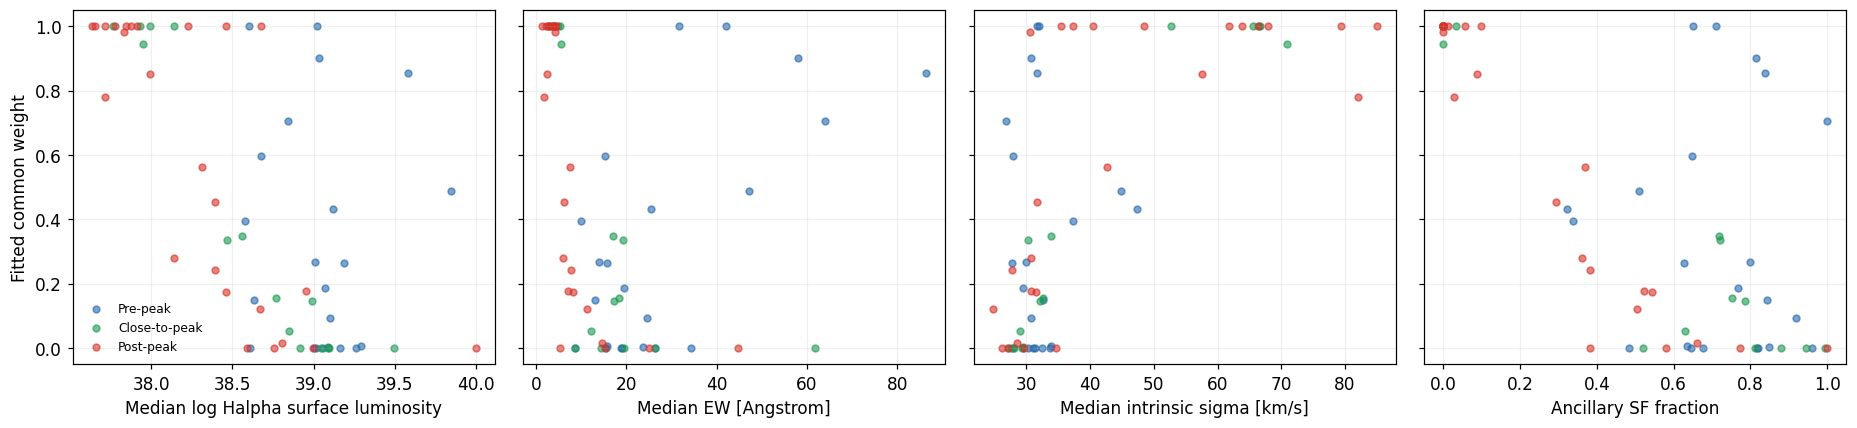

In [39]:
fig,axes=plt.subplots(1,4,figsize=(17,4),sharey=True)
if not GALAXY_CELL_FITS.empty:
    t=GALAXY_CELL_FITS.loc[GALAXY_CELL_FITS.DIG_selection.eq('DIG_L38.5')]
    for ax,field,label in zip(axes,('median_log_lha','median_EW','median_sigma','f_SF'),('Median log Halpha surface luminosity','Median EW [Angstrom]','Median intrinsic sigma [km/s]','Ancillary SF fraction')):
        for stage in STAGE_ORDER:
            g=t.loc[t.stage.eq(stage)];ax.scatter(g[field],g.joint_w,color=STAGE_COLORS[stage],s=20,alpha=.6,label=STAGE_LABELS[stage])
        ax.set_xlabel(label);ax.grid(alpha=.2)
axes[0].set_ylabel('Fitted common weight');axes[0].legend(frameon=False,fontsize=8)
fig.tight_layout();plt.show()

### Plot: forward forbidden-line predictions
The same fitted weight predicts NII and SII using measured Halpha and OIII using measured Hbeta. These are in-fit checks; the held-out-ratio plot provides the stronger diagnostic.

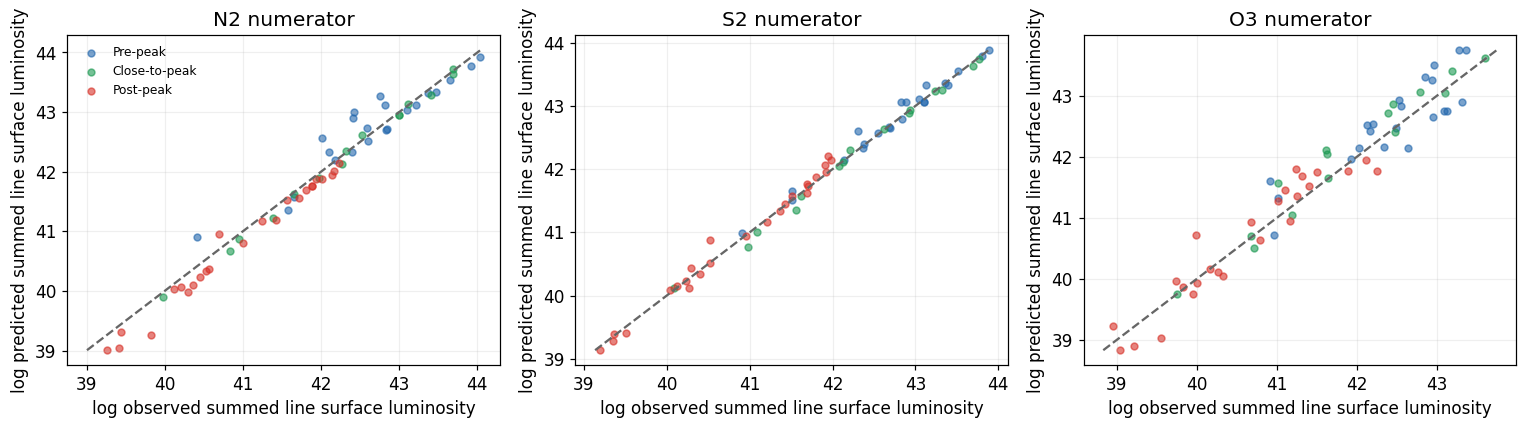

In [41]:
fig,axes=plt.subplots(1,3,figsize=(14,4))
if not GALAXY_CELL_FITS.empty:
    t=GALAXY_CELL_FITS.loc[GALAXY_CELL_FITS.DIG_selection.eq('DIG_L38.5')]
    for ax,k in zip(axes,RATIO_KEYS):
        x=np.log10(t['observed_line_'+k]);y=np.log10(t['predicted_line_'+k])
        for stage in STAGE_ORDER:
            use=t.stage.eq(stage);ax.scatter(x[use],y[use],color=STAGE_COLORS[stage],s=20,alpha=.6,label=STAGE_LABELS[stage])
        if len(t):
            limits=[min(x.min(),y.min()),max(x.max(),y.max())];ax.plot(limits,limits,color='.4',ls='--')
        ax.set_title(k+' numerator');ax.set_xlabel('log observed summed line surface luminosity');ax.set_ylabel('log predicted summed line surface luminosity');ax.grid(alpha=.2)
axes[0].legend(frameon=False,fontsize=8);fig.tight_layout();plt.show()

## Numerical verification and conditional interpretation

These checks validate implementation, not the physical purity of endpoints.
Synthetic checks exercise known weights, out-of-segment ratios and a spectrum
requiring inconsistent coordinate weights. Fresh live checks cover masks,
support, paired bootstrap bookkeeping and the joint weight bounds.

The Test 3 results are always labelled **conditional**. If Test 2 does not
place all ratios within the chosen practical tolerance on common support,
the notebook does not promote fixed-HII mixing to an established explanation.
Failure or disagreement can reflect endpoint uncertainty, remaining local
confounders, detection truncation, different physical spectra or extra components.
It does not identify a unique cause.

In [43]:
checks={}
H=np.array([.2,.15,.7]);D=np.array([.8,.65,.3]);truth=.37;O=H+truth*(D-H)
checks['synthetic_independent_weights']=np.allclose((O-H)/(D-H),truth)
checks['synthetic_joint_weight']=np.isclose(joint_weight(O,H,D,np.eye(3)),truth)
checks['synthetic_outside_endpoint_retained']=((H+1.3*(D-H)-H)/(D-H)>1).all()
bad=H+np.array([.2,.8,.1])*(D-H)
checks['synthetic_inconsistent_weights_detected']=np.ptp((bad-H)/(D-H))>.5
checks['all_stage_sample']=set(sample.stage)==set(STAGE_ORDER)
checks['no_bpt_class_in_primary_selection']=all('BPT' not in col for col in PURITY_GRID.columns)
checks['common_pixels_not_more_than_candidates']=bool((SELECTION_COUNTS.N_common<=SELECTION_COUNTS.N_candidate).all())
checks['supported_cells_meet_pixel_rules']=bool((MEASUREMENTS.loc[MEASUREMENTS.supported,'N_pixels']>=MIN_CELL_PIXELS).all() and (MEASUREMENTS.loc[MEASUREMENTS.supported,'N_usable']>=MIN_CELL_USABLE).all())
checks['all_supported_ratios_positive_finite']=bool(np.isfinite(MEASUREMENTS.loc[MEASUREMENTS.supported,list(RATIO_KEYS)]).all().all() and (MEASUREMENTS.loc[MEASUREMENTS.supported,list(RATIO_KEYS)]>0).all().all())
checks['shared_bootstrap_shape']=all(idx.shape==(N_BOOT,len(GALAXIES[s])) for s,idx in BOOT_INDICES.items())
checks['test2_intervals_ordered']=bool((TEST2_RESULTS.dropna(subset=['lo','hi']).lo<=TEST2_RESULTS.dropna(subset=['lo','hi']).hi).all())
finite_joint=MIX_RESULTS.joint_w.dropna()
checks['joint_weights_bounded']=bool(((finite_joint>=0)&(finite_joint<=1)).all())
checks['endpoint_qc_all_cells']=len(ENDPOINT_QC)==len(DIG_LOG_LHA_MAX_GRID)*len(STAGE_ORDER)*NC
checks['live_source_unchanged']=hashlib.sha256((PROJECT_ROOT/SOURCE_NOTEBOOK_NAME).read_bytes()).hexdigest()==SOURCE_NOTEBOOK_HASH
display(pd.Series(checks,name='passed').to_frame());assert all(checks.values()),checks
gate=TEST2_RESULTS.loc[TEST2_RESULTS.selection.eq(HII_ENDPOINT_SELECTION)]
TEST2_GATE=bool(len(gate)==6 and gate.status.eq('within exploratory tolerance').all())
print('Test 2 fixed-HII approximation within exploratory tolerance:',TEST2_GATE)
print('Test 3 is conditional; no automatic declaration of physical DIG fractions.')
display(gate)
display(ENDPOINT_QC.groupby(['DIG_selection','status']).size().rename('N_stage_cells'))
if not MIX_RESULTS.empty:
    eligible=MIX_RESULTS.loc[MIX_RESULTS.status.eq('eligible')]
    for k in RATIO_KEYS:
        w=eligible['w_'+k]
        held=eligible['heldout_'+k+'_dex']
        print(k,'identified stage/cells:',len(eligible),'central weights outside [0,1]:',int(((w<0)|(w>1)).sum()),
              'held-out central residual beyond tolerance:',int((held.abs()>JOINT_RESIDUAL_TOL_DEX).sum()))
print('TEST23_NOTEBOOK_VALIDATION_OK')

Test 2 fixed-HII approximation within exploratory tolerance: False
Test 3 is conditional; no automatic declaration of physical DIG fractions.
N2 identified stage/cells: 12 central weights outside [0,1]: 7 held-out central residual beyond tolerance: 6
S2 identified stage/cells: 12 central weights outside [0,1]: 0 held-out central residual beyond tolerance: 4
O3 identified stage/cells: 12 central weights outside [0,1]: 6 held-out central residual beyond tolerance: 8
TEST23_NOTEBOOK_VALIDATION_OK


,passed
synthetic_independent_weights,True
synthetic_joint_weight,True
synthetic_outside_endpoint_retained,True
synthetic_inconsistent_weights_detected,True
all_stage_sample,True
no_bpt_class_in_primary_selection,True
common_pixels_not_more_than_candidates,True
supported_cells_meet_pixel_rules,True
all_supported_ratios_positive_finite,True
shared_bootstrap_shape,True


,selection,stage,ratio,N_matched_cells,N_finite_draws,delta_dex,lo,hi,status
102,E50_L39.5_S35,close-to-peak,N2,3,1972,0.023587,-0.020583,0.064155,inconclusive
103,E50_L39.5_S35,close-to-peak,S2,3,1972,-0.076669,-0.123877,-0.031346,inconclusive
104,E50_L39.5_S35,close-to-peak,O3,3,1972,-0.225596,-0.448580,-0.001245,inconclusive
105,E50_L39.5_S35,post-peak,N2,3,1967,0.081845,0.033623,0.127152,inconclusive
106,E50_L39.5_S35,post-peak,S2,3,1967,-0.082877,-0.116153,-0.048322,inconclusive
107,E50_L39.5_S35,post-peak,O3,3,1967,-0.437287,-0.572999,-0.289720,offset beyond tolerance


DIG_selection  status                            
DIG_L38.5      eligible                               6
               insufficient support                  43
               unequal corrected Balmer endpoints     3
               weak endpoint separation               8
DIG_L39        eligible                               6
               insufficient support                  40
               weak endpoint separation              14
Name: N_stage_cells, dtype: int64

### What remains before a physical interpretation

1. Inspect morphology and sigma-fit quality; replace peak-distance and central
   proxies with independent HII/AGN/bulge information where available.
2. Assess the missing low-brightness forbidden-line population; this notebook
   analyses detections and does not model upper limits.
3. Check cut and bin-width sensitivity, bootstrap convergence, and enough
   independent galaxies. Threshold-grid panels share data and are not independent tests.
4. A narrower stage interval around zero does not prove invariant spectra.
   Metallicity, ionization parameter, stellar age, resolution and inclination
   can remain confounders; no BPT-derived metallicity is used as an independent control.
5. Bootstrap intervals include galaxy and empirical-template sampling variation,
   but not line-fit, dust-law, instrumental-resolution or geometry systematics.
6. A rejected fixed segment rejects those endpoint choices on the measured
   support; it does not uniquely establish shocks, HOLMES or intrinsic HII evolution.